# Dissertation Title :  Evaluating a Machine Learning-Based Prototype for Early Mental Health Prediction Using Multiple Predictive Models

# Importing Required Libraries , Loading the Dataset & Basic Few Operations 

In [3]:
# I imported the NumPy library for numerical computations.
import numpy as np

# I imported the Pandas library for data manipulation.
import pandas as pd

# I imported Matplotlib for data visualisation.
import matplotlib.pyplot as plt

# I imported the Seaborn library for statistical visualisation.
import seaborn as sb

# I loaded the dataset into a DataFrame.
df = pd.read_csv("Mental_Health_Dataset.csv")

# I displayed the first five records of the dataset.
print(df.head())

# I displayed the shape of the dataset.
print("Dataset Shape:", df.shape)

# I displayed the data types of all columns.
print("Data Types:", (df.dtypes))

         Timestamp Gender         Country Occupation self_employed  \
0  8/28/2014 10:10   Male     Netherlands  Corporate            No   
1  8/27/2014 16:34   Male         Germany     Others            No   
2  8/27/2014 13:26   Male  United Kingdom  Housewife            No   
3  8/28/2014 17:31   Male           India     Others           Yes   
4  8/27/2014 12:39   Male   United States    Student            No   

  family_history treatment      Days_Indoors Growing_Stress Changes_Habits  \
0            Yes        No        31-60 days            Yes          Maybe   
1             No        No  Go out Every day            Yes            Yes   
2             No        No  Go out Every day             No            Yes   
3             No        No        31-60 days          Maybe            Yes   
4             No        No         1-14 days             No            Yes   

  Mental_Health_History Mood_Swings Coping_Struggles Work_Interest  \
0                   Yes         Low     

# Data Inspection 

In [4]:
# I displayed the total number of observations in the dataset.
print("Number of Observations:", df.shape[0])

# I displayed the total number of features in the dataset.
print("Number of Features:", df.shape[1])

# I displayed the names of all features.
print("\nFeature Names:")
print(df.columns.tolist())

# I specified the target variable.
target_variable = "treatment"

# I displayed the target variable.
print("\nTarget Variable:")
print(target_variable)

# I identified the independent variables.
independent_variables = [column for column in df.columns if column != target_variable]

# I displayed the independent variables.
print("\nIndependent Variables:")
print(independent_variables)

# I displayed the number of independent variables.
print("\nNumber of Independent Variables:", len(independent_variables))

# I displayed the categories of the target variable.
print("\nCategories of Target Variable:")
print(df[target_variable].unique())

Number of Observations: 20000
Number of Features: 17

Feature Names:
['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

Target Variable:
treatment

Independent Variables:
['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

Number of Independent Variables: 16

Categories of Target Variable:
['No' 'Yes']


# Data Pre-Processing 

In [37]:
# I displayed the total number of missing values before preprocessing.
print("Missing Values Before Preprocessing:")
print(df.isnull().sum())

# I displayed the total number of duplicate records before preprocessing.
print("\nDuplicate Records Before Preprocessing:")
print(df.duplicated().sum())

# I removed duplicate records from the dataset.
df = df.drop_duplicates()

# I reset the index after removing duplicate records.
df.reset_index(drop=True, inplace=True)

# I removed the Timestamp feature because it did not contribute meaningful information for prediction.
df = df.drop("Timestamp", axis=1)

# I filled the missing values in each categorical feature using the mode.
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])

# I displayed the total number of missing values after preprocessing.
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# I imported the LabelEncoder class.
from sklearn.preprocessing import LabelEncoder

# I created a dictionary to store the label encoders.
label_encoders = {}

# I applied Label Encoding to all categorical features.
for column in df.columns:
    if df[column].dtype == "object":
        encoder = LabelEncoder()
        df[column] = encoder.fit_transform(df[column])
        label_encoders[column] = encoder

# I separated the independent variables and the target variable.
X = df.drop("treatment", axis=1)

# I separated the target variable.
y = df["treatment"]

# I displayed the shape of the independent variables.
print("\nIndependent Variable Shape:", X.shape)

# I displayed the shape of the target variable.
print("Target Variable Shape:", y.shape)

# I displayed the first five rows of the preprocessed dataset.
print("\nPreprocessed Dataset:")
print(df.head())

Missing Values Before Preprocessing:
Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

Duplicate Records Before Preprocessing:
0

Missing Values After Preprocessing:
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0


# Exploratory Data Analysis 

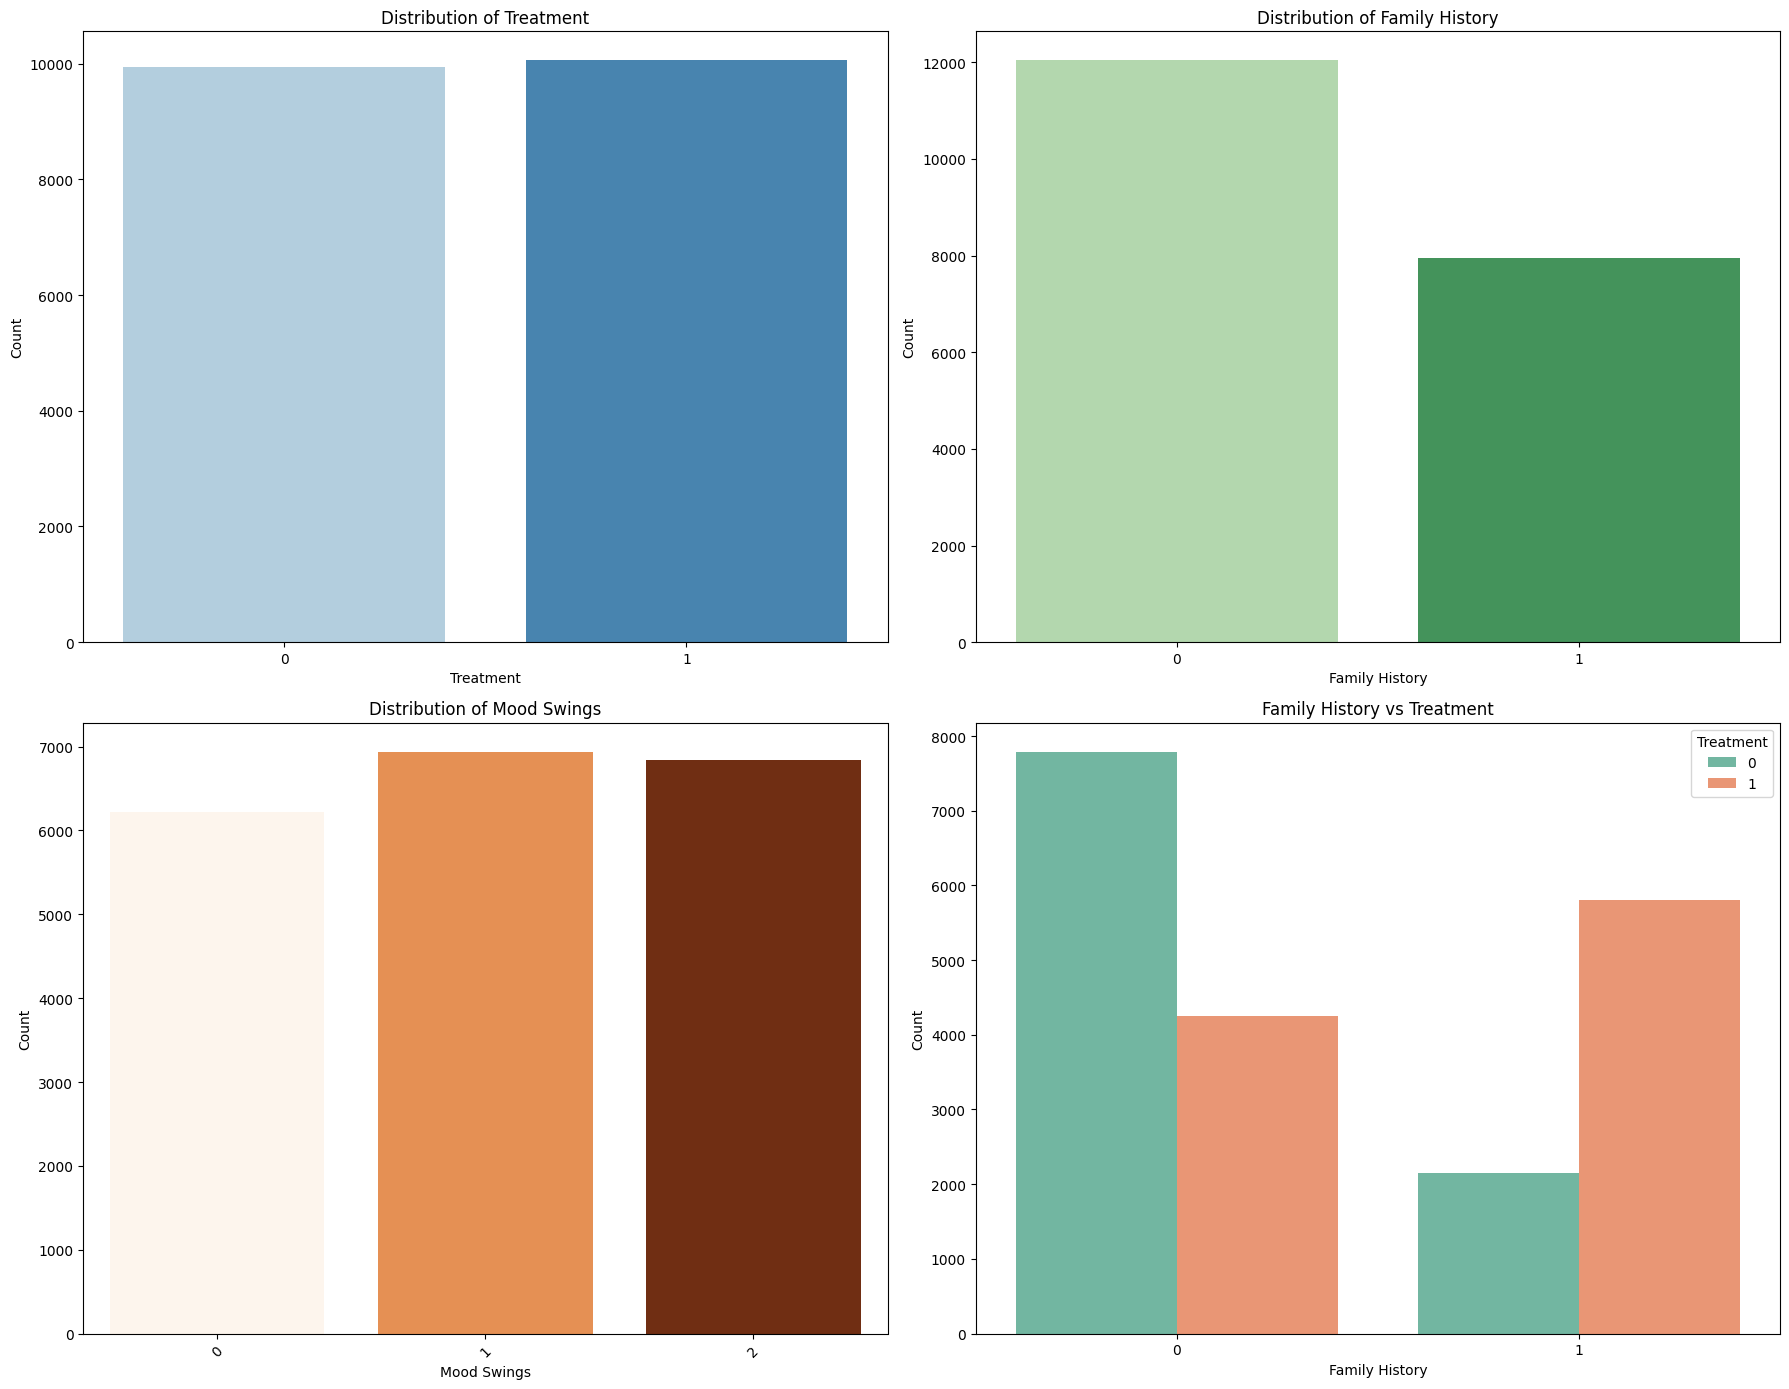

In [38]:
# I created a figure to display all exploratory data analysis plots.
plt.figure(figsize=(18, 14))

# I visualised the distribution of the target variable.
plt.subplot(2, 2, 1)
sb.countplot(data=df, x="treatment", hue="treatment", palette="Blues", legend=False)
plt.title("Distribution of Treatment")
plt.xlabel("Treatment")
plt.ylabel("Count")

# I visualised the distribution of family history.
plt.subplot(2, 2, 2)
sb.countplot(data=df, x="family_history", hue="family_history", palette="Greens", legend=False)
plt.title("Distribution of Family History")
plt.xlabel("Family History")
plt.ylabel("Count")

# I visualised the distribution of mood swings.
plt.subplot(2, 2, 3)
sb.countplot(data=df, x="Mood_Swings", hue="Mood_Swings", palette="Oranges", legend=False)
plt.title("Distribution of Mood Swings")
plt.xlabel("Mood Swings")
plt.ylabel("Count")
plt.xticks(rotation=45)

# I visualised the relationship between family history and treatment.
plt.subplot(2, 2, 4)
sb.countplot(data=df, x="family_history", hue="treatment", palette="Set2")
plt.title("Family History vs Treatment")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.legend(title="Treatment")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed all exploratory data analysis plots.
plt.show()

# Splitting the Dataset 

In [39]:
# I imported the train_test_split function.
from sklearn.model_selection import train_test_split

# I split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the shape of the training independent variables.
print("Training Independent Variables Shape:", X_train.shape)

# I displayed the shape of the testing independent variables.
print("Testing Independent Variables Shape:", X_test.shape)

# I displayed the shape of the training target variable.
print("Training Target Variable Shape:", y_train.shape)

# I displayed the shape of the testing target variable.
print("Testing Target Variable Shape:", y_test.shape)

# I displayed the class distribution of the training target variable.
print("\nTraining Target Distribution:")
print(pd.Series(y_train).value_counts())

# I displayed the class distribution of the testing target variable.
print("\nTesting Target Distribution:")
print(pd.Series(y_test).value_counts())

Training Independent Variables Shape: (15991, 15)
Testing Independent Variables Shape: (3998, 15)
Training Target Variable Shape: (15991,)
Testing Target Variable Shape: (3998,)

Training Target Distribution:
treatment
1    8044
0    7947
Name: count, dtype: int64

Testing Target Distribution:
treatment
1    2011
0    1987
Name: count, dtype: int64


# Model Training & Evaluation 

# Baseline Models 

# Model 1 : Logistic Regression 

Logistic Regression Performance
Accuracy : 0.6946
Precision: 0.7051
Recall   : 0.6753
F1-Score : 0.6899
ROC-AUC  : 0.7492

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.71      0.70      1987
           1       0.71      0.68      0.69      2011

    accuracy                           0.69      3998
   macro avg       0.69      0.69      0.69      3998
weighted avg       0.70      0.69      0.69      3998



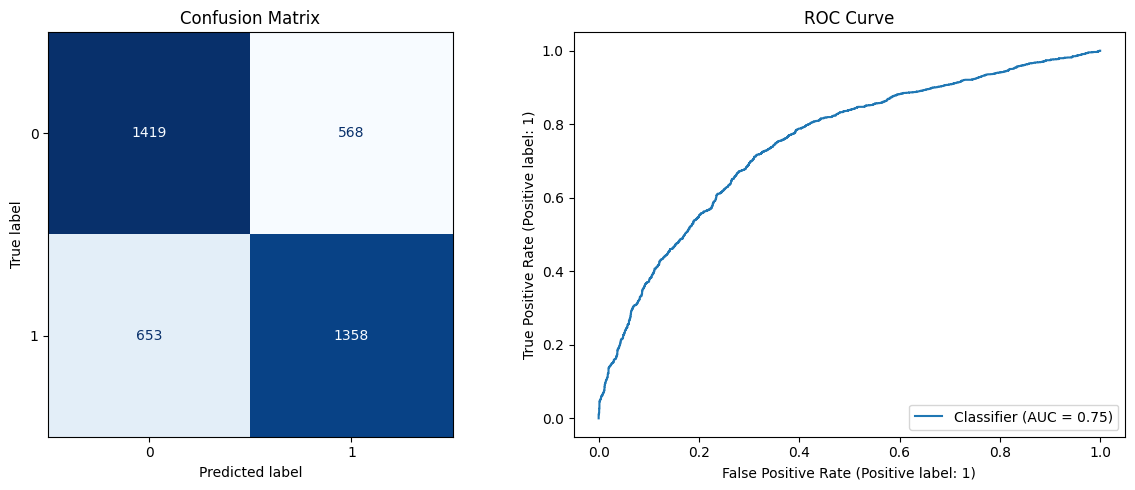

In [46]:
# I imported the Logistic Regression algorithm.
from sklearn.linear_model import LogisticRegression

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I created the Logistic Regression model.
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# I trained the Logistic Regression model.
lr_model.fit(X_train, y_train)

# I predicted the target values for the testing dataset.
y_pred = lr_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = lr_model.predict_proba(X_test)[:, 1]

# I calculated and stored the accuracy.
base_lr_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the precision.
base_lr_precision = precision_score(y_test, y_pred)

# I calculated and stored the recall.
base_lr_recall = recall_score(y_test, y_pred)

# I calculated and stored the F1-score.
base_lr_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the ROC-AUC score.
base_lr_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the evaluation results.
print("Logistic Regression Performance")

print("Accuracy :", round(base_lr_accuracy, 4))
print("Precision:", round(base_lr_precision, 4))
print("Recall   :", round(base_lr_recall, 4))
print("F1-Score :", round(base_lr_f1_score, 4))
print("ROC-AUC  :", round(base_lr_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 2 : Random Forest 

Random Forest Performance
Accuracy : 0.6963
Precision: 0.7024
Recall   : 0.6877
F1-Score : 0.695
ROC-AUC  : 0.7492

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      1987
           1       0.70      0.69      0.69      2011

    accuracy                           0.70      3998
   macro avg       0.70      0.70      0.70      3998
weighted avg       0.70      0.70      0.70      3998



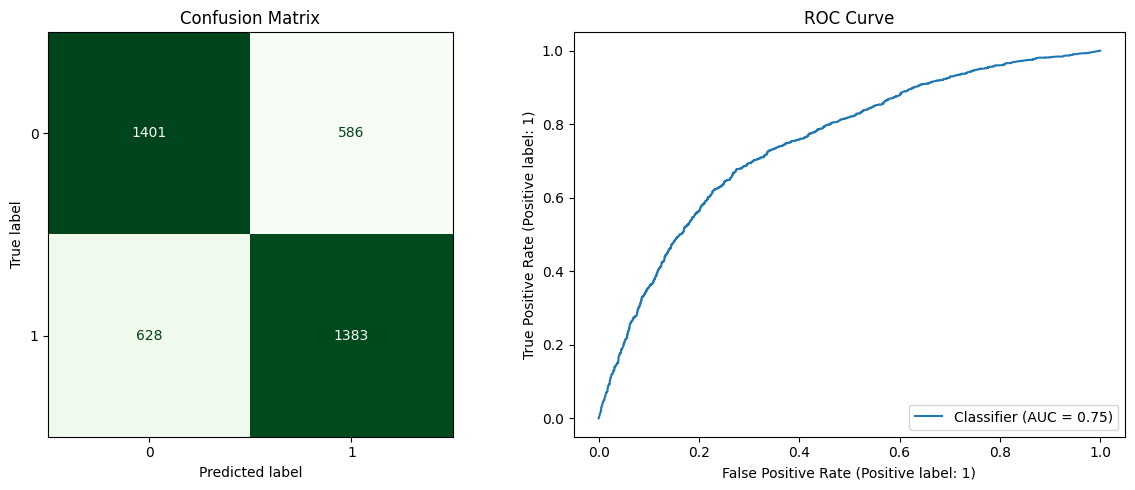

In [47]:
# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I created the Random Forest model.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# I trained the Random Forest model.
rf_model.fit(X_train, y_train)

# I predicted the target values for the testing dataset.
y_pred = rf_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = rf_model.predict_proba(X_test)[:, 1]

# I calculated and stored the accuracy.
base_rf_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the precision.
base_rf_precision = precision_score(y_test, y_pred)

# I calculated and stored the recall.
base_rf_recall = recall_score(y_test, y_pred)

# I calculated and stored the F1-score.
base_rf_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the ROC-AUC score.
base_rf_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the evaluation results.
print("Random Forest Performance")

print("Accuracy :", round(base_rf_accuracy, 4))
print("Precision:", round(base_rf_precision, 4))
print("Recall   :", round(base_rf_recall, 4))
print("F1-Score :", round(base_rf_f1_score, 4))
print("ROC-AUC  :", round(base_rf_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Greens",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 3 : CatBoost 

CatBoost Performance
Accuracy : 0.7606
Precision: 0.7551
Recall   : 0.7757
F1-Score : 0.7653
ROC-AUC  : 0.8318

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1987
           1       0.76      0.78      0.77      2011

    accuracy                           0.76      3998
   macro avg       0.76      0.76      0.76      3998
weighted avg       0.76      0.76      0.76      3998



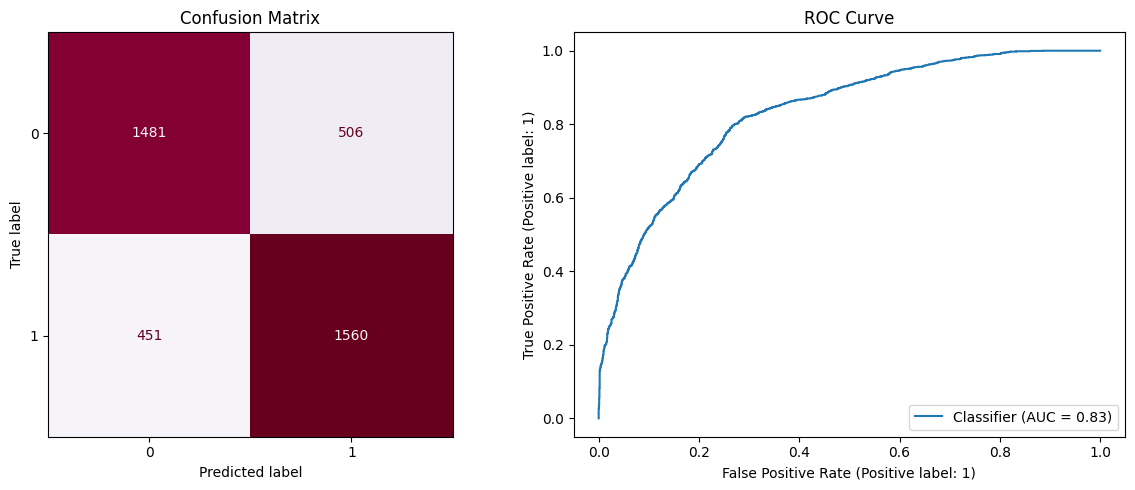

In [48]:
# I imported the CatBoost classifier.
from catboost import CatBoostClassifier

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I created the CatBoost model.
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

# I trained the CatBoost model.
cat_model.fit(X_train, y_train)

# I predicted the target values for the testing dataset.
y_pred = cat_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = cat_model.predict_proba(X_test)[:, 1]

# I calculated and stored the accuracy.
base_cat_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the precision.
base_cat_precision = precision_score(y_test, y_pred)

# I calculated and stored the recall.
base_cat_recall = recall_score(y_test, y_pred)

# I calculated and stored the F1-score.
base_cat_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the ROC-AUC score.
base_cat_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the evaluation results.
print("CatBoost Performance")
print("Accuracy :", round(base_cat_accuracy, 4))
print("Precision:", round(base_cat_precision, 4))
print("Recall   :", round(base_cat_recall, 4))
print("F1-Score :", round(base_cat_f1_score, 4))
print("ROC-AUC  :", round(base_cat_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="PuRd",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 4 : Gradient Boosting 

Gradient Boosting Performance
Accuracy : 0.7411
Precision: 0.7406
Recall   : 0.7469
F1-Score : 0.7437
ROC-AUC  : 0.8079

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1987
           1       0.74      0.75      0.74      2011

    accuracy                           0.74      3998
   macro avg       0.74      0.74      0.74      3998
weighted avg       0.74      0.74      0.74      3998



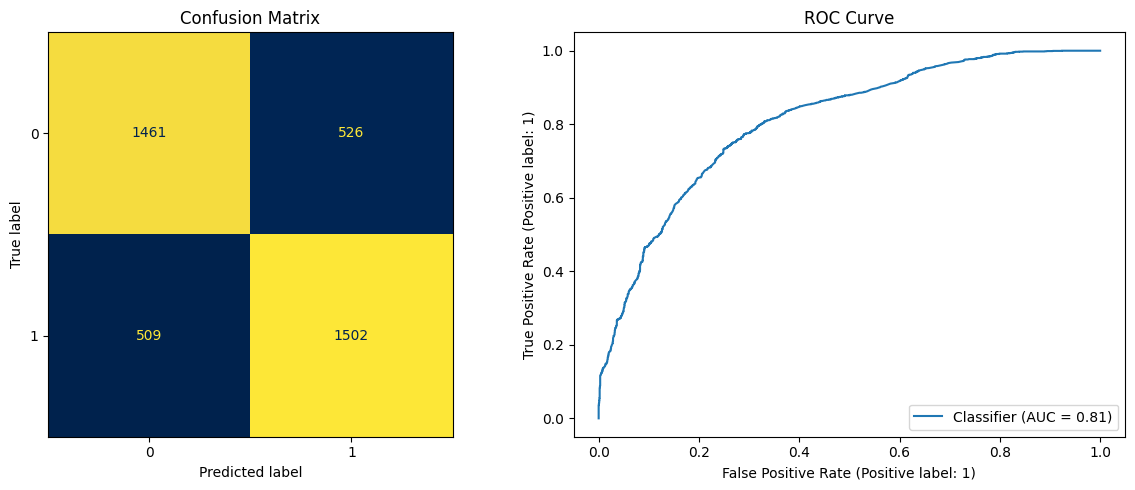

In [49]:
# I imported the Gradient Boosting classifier.
from sklearn.ensemble import GradientBoostingClassifier

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I created the Gradient Boosting model.
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# I trained the Gradient Boosting model.
gb_model.fit(X_train, y_train)

# I predicted the target values for the testing dataset.
y_pred = gb_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = gb_model.predict_proba(X_test)[:, 1]

# I calculated and stored the accuracy.
base_gb_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the precision.
base_gb_precision = precision_score(y_test, y_pred)

# I calculated and stored the recall.
base_gb_recall = recall_score(y_test, y_pred)

# I calculated and stored the F1-score.
base_gb_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the ROC-AUC score.
base_gb_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the evaluation results.
print("Gradient Boosting Performance")
print("Accuracy :", round(base_gb_accuracy, 4))
print("Precision:", round(base_gb_precision, 4))
print("Recall   :", round(base_gb_recall, 4))
print("F1-Score :", round(base_gb_f1_score, 4))
print("ROC-AUC  :", round(base_gb_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="cividis",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Combined Comparative Table for all Baseline Models 

In [50]:
# I created a comparative performance table for all baseline models.
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Gradient Boosting"
    ],
    "Accuracy": [
        base_lr_accuracy,
        base_rf_accuracy,
        base_cat_accuracy,
        base_gb_accuracy
    ],
    "Precision": [
        base_lr_precision,
        base_rf_precision,
        base_cat_precision,
        base_gb_precision
    ],
    "Recall": [
        base_lr_recall,
        base_rf_recall,
        base_cat_recall,
        base_gb_recall
    ],
    "F1-Score": [
        base_lr_f1_score,
        base_rf_f1_score,
        base_cat_f1_score,
        base_gb_f1_score
    ],
    "ROC-AUC": [
        base_lr_roc_auc,
        base_rf_roc_auc,
        base_cat_roc_auc,
        base_gb_roc_auc
    ]
})

# I rounded the evaluation metrics.
baseline_results.iloc[:,1:] = baseline_results.iloc[:,1:].round(4)

# I created a function to apply different colours to each model.
def highlight_models(row):
    if row["Model"] == "Logistic Regression":
        return ["background-color:#D6EAF8"] * len(row)
    elif row["Model"] == "Random Forest":
        return ["background-color:#D5F5E3"] * len(row)
    elif row["Model"] == "CatBoost":
        return ["background-color:#E8DAEF"] * len(row)
    elif row["Model"] == "Gradient Boosting":
        return ["background-color:#FAD7A0"] * len(row)
    else:
        return [""] * len(row)

# I displayed the colourful comparative table.
display(
    baseline_results.style
    .apply(highlight_models, axis=1)
    .set_properties(**{
        "text-align":"center",
        "border":"1px solid black",
        "font-size":"12pt"
    })
    .set_table_styles([
        {
            "selector":"th",
            "props":[
                ("background-color","#2E4053"),
                ("color","white"),
                ("font-size","13pt"),
                ("font-weight","bold"),
                ("text-align","center"),
                ("border","1px solid black")
            ]
        },
        {
            "selector":"td",
            "props":[
                ("border","1px solid black"),
                ("text-align","center")
            ]
        }
    ])
    .hide(axis="index")
)

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.694600,0.705100,0.675300,0.689900,0.749200
Random Forest,0.696300,0.702400,0.687700,0.695000,0.749200
CatBoost,0.760600,0.755100,0.775700,0.765300,0.831800
Gradient Boosting,0.741100,0.740600,0.746900,0.743700,0.807900


# Graphs for Each Metrics for all Baseline Models 

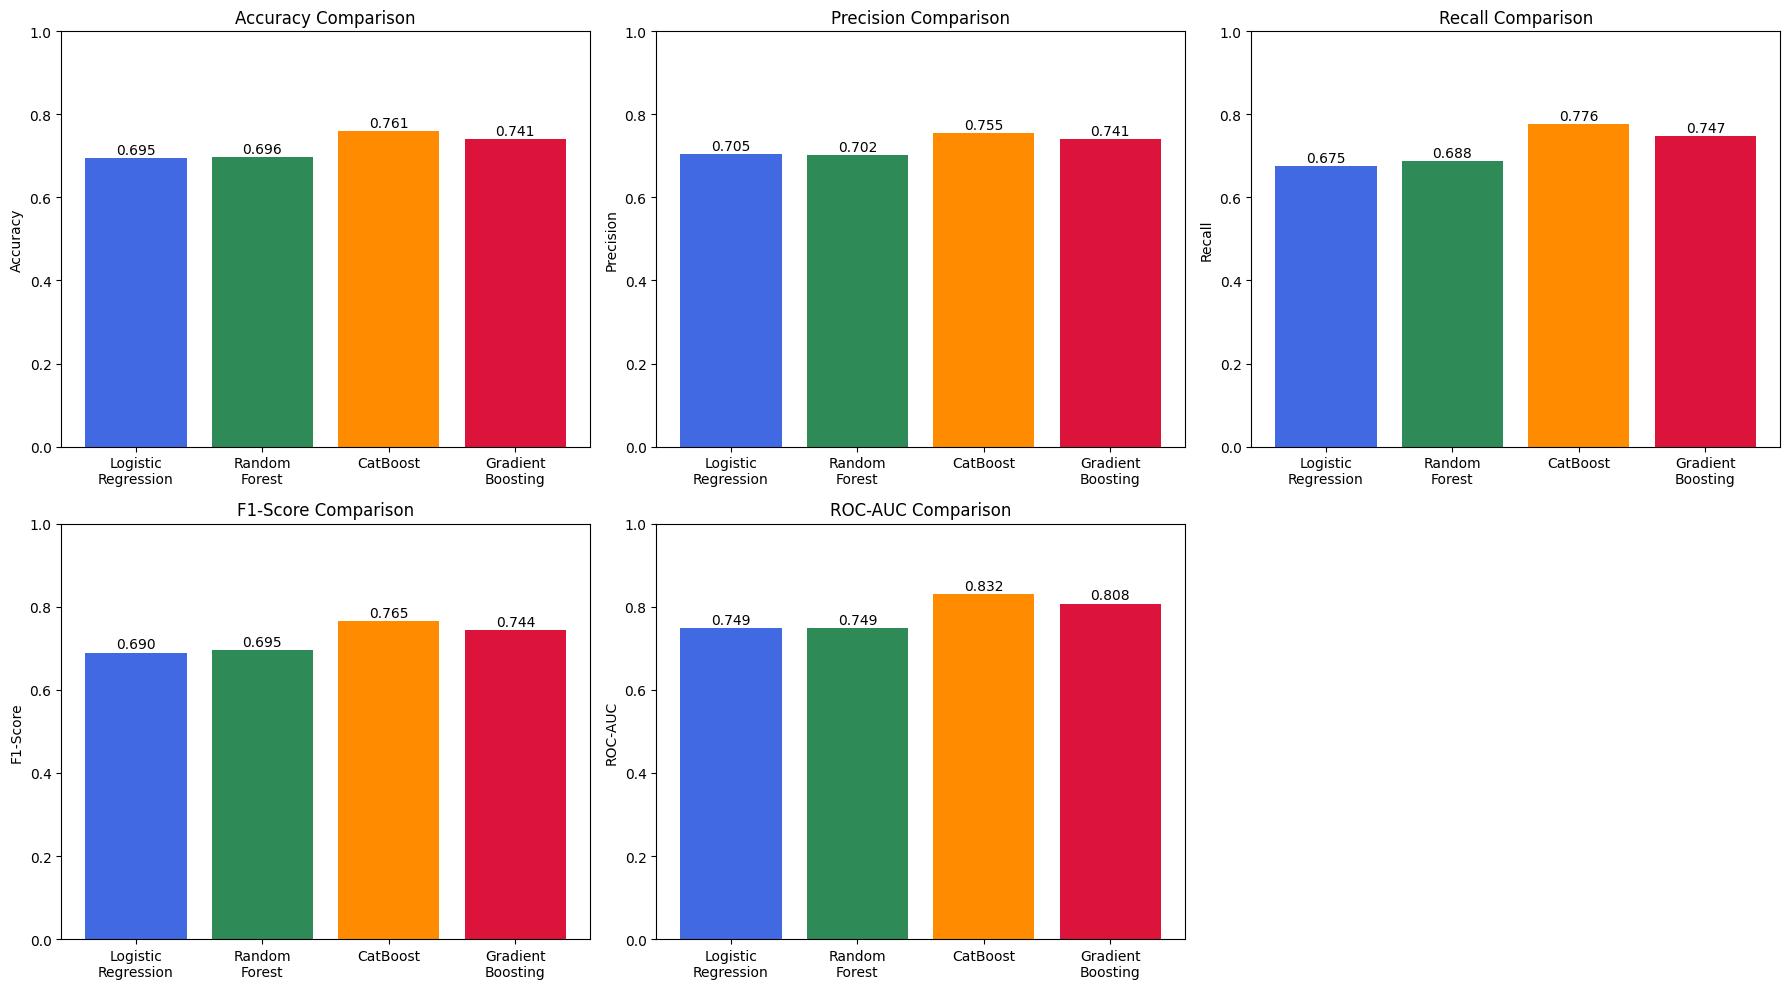

In [51]:
# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the evaluation metrics for each model.
accuracy = [
    base_lr_accuracy,
    base_rf_accuracy,
    base_cat_accuracy,
    base_gb_accuracy
]

precision = [
    base_lr_precision,
    base_rf_precision,
    base_cat_precision,
    base_gb_precision
]

recall = [
    base_lr_recall,
    base_rf_recall,
    base_cat_recall,
    base_gb_recall
]

f1_score = [
    base_lr_f1_score,
    base_rf_f1_score,
    base_cat_f1_score,
    base_gb_f1_score
]

roc_auc = [
    base_lr_roc_auc,
    base_rf_roc_auc,
    base_cat_roc_auc,
    base_gb_roc_auc
]

# I defined different colours for each model.
colors = ["royalblue", "seagreen", "darkorange", "crimson"]

# I created a figure to display all evaluation graphs.
plt.figure(figsize=(18, 10))

# I plotted the Accuracy comparison.
plt.subplot(2, 3, 1)
plt.bar(models, accuracy, color=colors)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# I plotted the Precision comparison.
plt.subplot(2, 3, 2)
plt.bar(models, precision, color=colors)
plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0, 1)
for i, v in enumerate(precision):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# I plotted the Recall comparison.
plt.subplot(2, 3, 3)
plt.bar(models, recall, color=colors)
plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0, 1)
for i, v in enumerate(recall):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# I plotted the F1-Score comparison.
plt.subplot(2, 3, 4)
plt.bar(models, f1_score, color=colors)
plt.title("F1-Score Comparison")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
for i, v in enumerate(f1_score):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# I plotted the ROC-AUC comparison.
plt.subplot(2, 3, 5)
plt.bar(models, roc_auc, color=colors)
plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
for i, v in enumerate(roc_auc):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# I removed the unused subplot.
plt.subplot(2, 3, 6)
plt.axis("off")

# I adjusted the spacing between the graphs.
plt.tight_layout()

# I displayed all evaluation graphs.
plt.show()

# Combined Comparative Bar Graph for all Baseline Models 

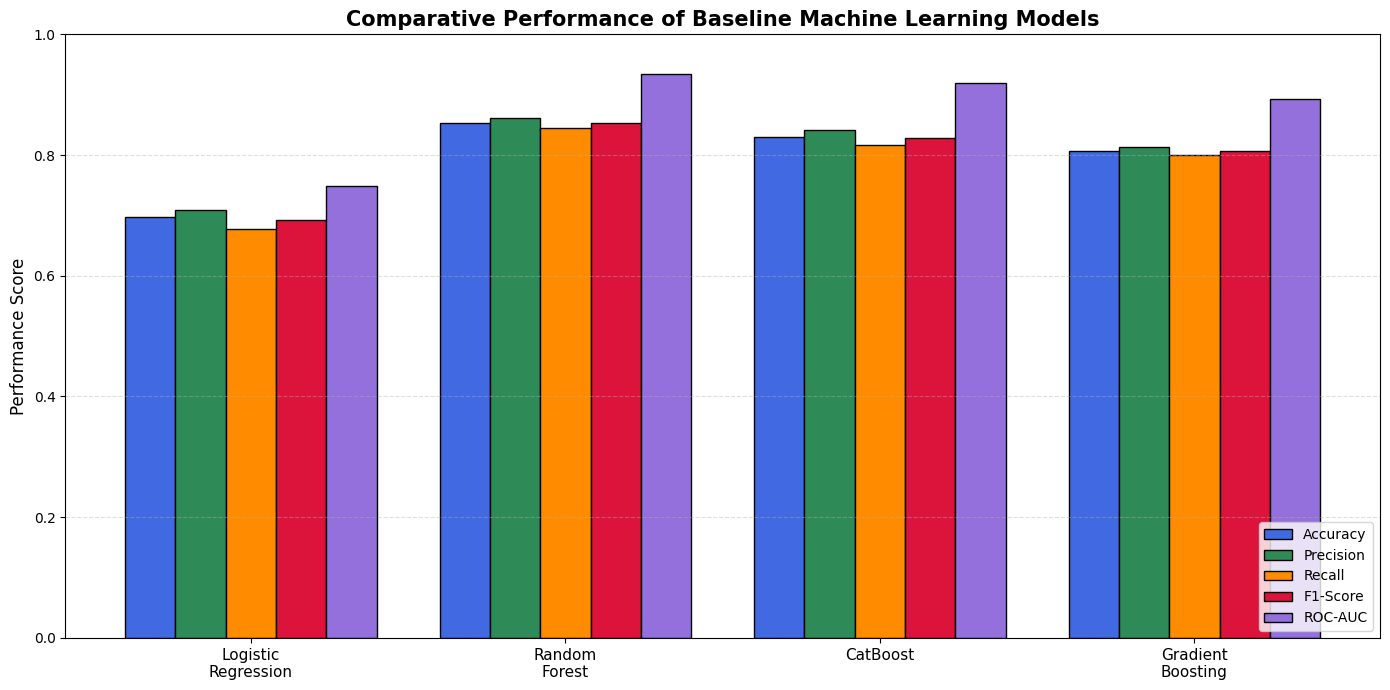

In [25]:
# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the evaluation metrics for each model.
accuracy = [base_lr_accuracy, base_rf_accuracy, base_cat_accuracy, base_gb_accuracy]
precision = [base_lr_precision, base_rf_precision, base_cat_precision, base_gb_precision]
recall = [base_lr_recall, base_rf_recall, base_cat_recall, base_gb_recall]
f1 = [base_lr_f1_score, base_rf_f1_score, base_cat_f1_score, base_gb_f1_score]
roc_auc = [base_lr_roc_auc, base_rf_roc_auc, base_cat_roc_auc, base_gb_roc_auc]

# I imported NumPy.
import numpy as np

# I created the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.16

# I created the comparison figure.
plt.figure(figsize=(14,7))

# I plotted the Accuracy bars.
plt.bar(x - 2*width, accuracy, width,
        label="Accuracy",
        color="royalblue",
        edgecolor="black")

# I plotted the Precision bars.
plt.bar(x - width, precision, width,
        label="Precision",
        color="seagreen",
        edgecolor="black")

# I plotted the Recall bars.
plt.bar(x, recall, width,
        label="Recall",
        color="darkorange",
        edgecolor="black")

# I plotted the F1-Score bars.
plt.bar(x + width, f1, width,
        label="F1-Score",
        color="crimson",
        edgecolor="black")

# I plotted the ROC-AUC bars.
plt.bar(x + 2*width, roc_auc, width,
        label="ROC-AUC",
        color="mediumpurple",
        edgecolor="black")

# I added the x-axis labels.
plt.xticks(x, models, fontsize=11)

# I added the y-axis label.
plt.ylabel("Performance Score", fontsize=12)

# I added the graph title.
plt.title("Comparative Performance of Baseline Machine Learning Models",
          fontsize=15,
          fontweight="bold")

# I limited the y-axis.
plt.ylim(0, 1)

# I displayed the legend.
plt.legend(loc="lower right")

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I displayed the graph.
plt.tight_layout()
plt.show()

# Combined Comparative F1-Score Bar Graph for all Baseline Models 

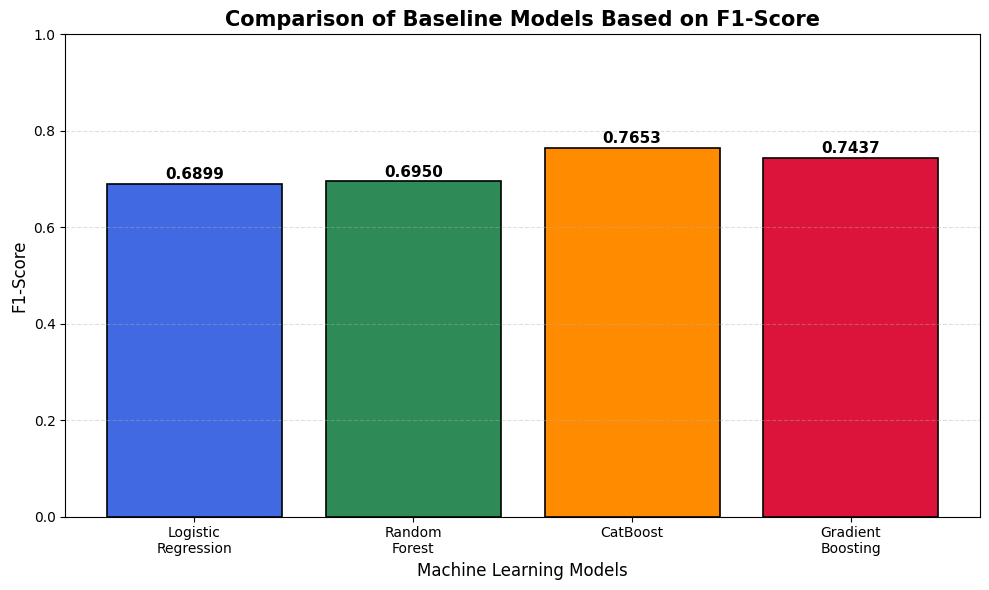

In [52]:
# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the F1-Score values for all baseline models.
f1_scores = [
    base_lr_f1_score,
    base_rf_f1_score,
    base_cat_f1_score,
    base_gb_f1_score
]

# I defined different colours for each model.
colors = [
    "royalblue",
    "seagreen",
    "darkorange",
    "crimson"
]

# I created the figure.
plt.figure(figsize=(10,6))

# I plotted the F1-Score comparison.
bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I added the graph title.
plt.title(
    "Comparison of Baseline Models Based on F1-Score",
    fontsize=15,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel("Machine Learning Models", fontsize=12)

# I added the y-axis label.
plt.ylabel("F1-Score", fontsize=12)

# I limited the y-axis.
plt.ylim(0, 1)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I displayed the graph.
plt.tight_layout()
plt.show()

# Combined AUC-ROC Curve for all Baseline Models 

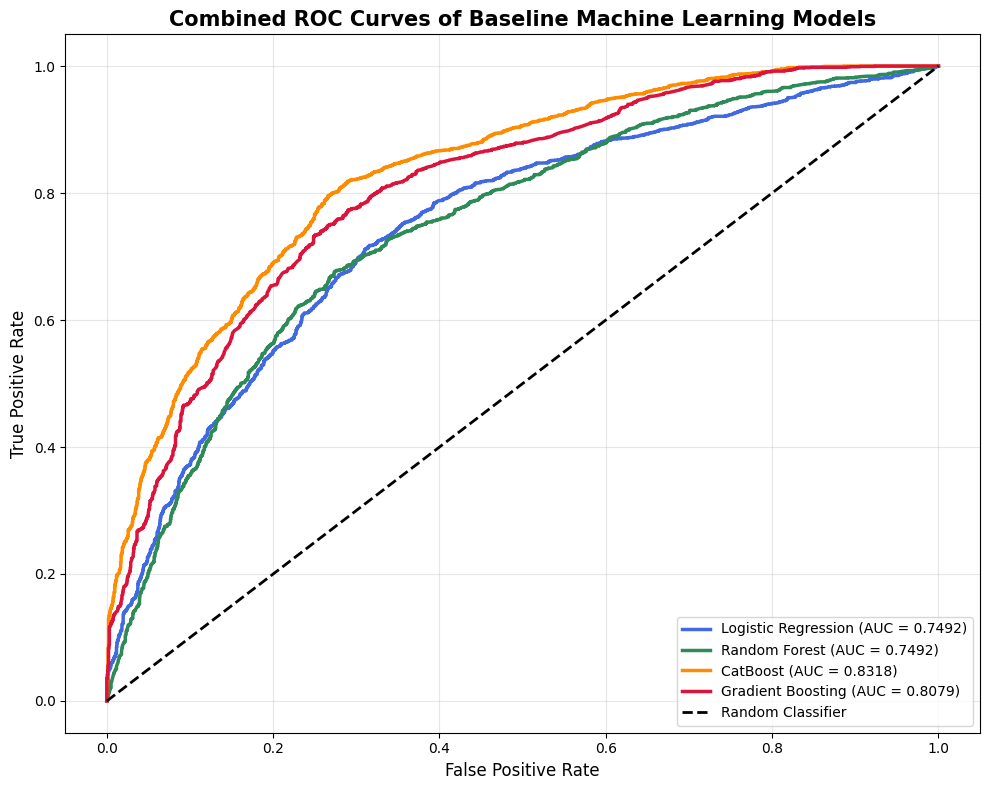

In [53]:
# I imported the required functions for plotting ROC curves.
from sklearn.metrics import roc_curve, auc

# I predicted the probabilities for each baseline model.
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
cat_prob = cat_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# I calculated the ROC curve for Logistic Regression.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = auc(lr_fpr, lr_tpr)

# I calculated the ROC curve for Random Forest.
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# I calculated the ROC curve for CatBoost.
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
cat_auc = auc(cat_fpr, cat_tpr)

# I calculated the ROC curve for Gradient Boosting.
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
gb_auc = auc(gb_fpr, gb_tpr)

# I created the ROC curve figure.
plt.figure(figsize=(10,8))

# I plotted the ROC curve for Logistic Regression.
plt.plot(
    lr_fpr,
    lr_tpr,
    color="royalblue",
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

# I plotted the ROC curve for Random Forest.
plt.plot(
    rf_fpr,
    rf_tpr,
    color="seagreen",
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

# I plotted the ROC curve for CatBoost.
plt.plot(
    cat_fpr,
    cat_tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"CatBoost (AUC = {cat_auc:.4f})"
)

# I plotted the ROC curve for Gradient Boosting.
plt.plot(
    gb_fpr,
    gb_tpr,
    color="crimson",
    linewidth=2.5,
    label=f"Gradient Boosting (AUC = {gb_auc:.4f})"
)

# I plotted the random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

# I added the graph title.
plt.title(
    "Combined ROC Curves of Baseline Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel("False Positive Rate", fontsize=12)

# I added the y-axis label.
plt.ylabel("True Positive Rate", fontsize=12)

# I displayed the legend.
plt.legend(loc="lower right", fontsize=10)

# I added grid lines.
plt.grid(alpha=0.3)

# I displayed the graph.
plt.tight_layout()
plt.show()

# HyperParameter Tuning 

# Model 1 : Tuned Logistic Regression 

Best Hyperparameters:
{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}

Tuned Logistic Regression Performance
Accuracy : 0.6941
Precision: 0.7037
Recall   : 0.6768
F1-Score : 0.69
ROC-AUC  : 0.7492

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      1987
           1       0.70      0.68      0.69      2011

    accuracy                           0.69      3998
   macro avg       0.69      0.69      0.69      3998
weighted avg       0.69      0.69      0.69      3998



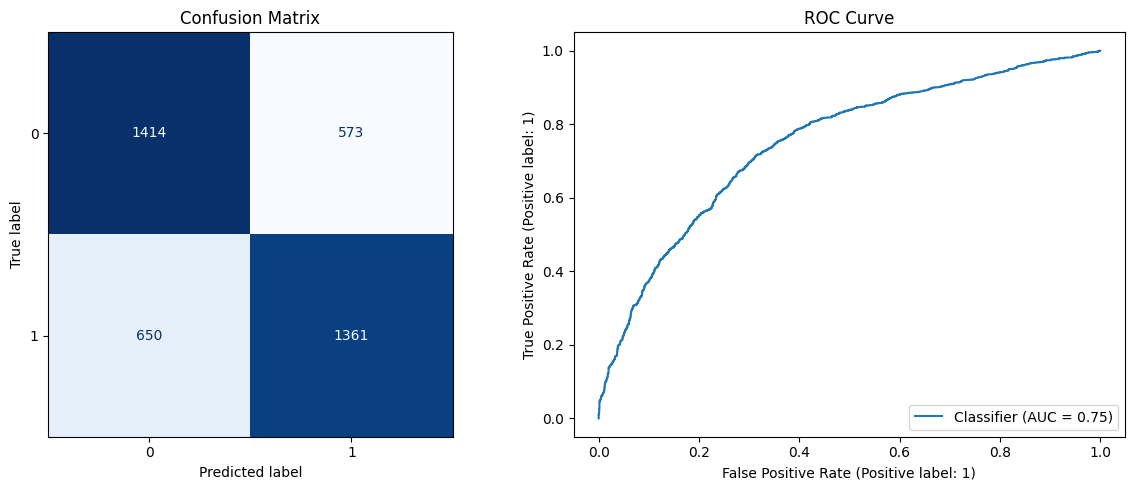

In [54]:
# I imported the Logistic Regression algorithm.
from sklearn.linear_model import LogisticRegression

# I imported the RandomizedSearchCV class.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I defined the hyperparameter search space.
param_dist = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"]
}

# I created the Logistic Regression model.
lr_model = LogisticRegression(random_state=42)

# I created the Randomized Search object.
random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_dist,
    n_iter=5,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# I trained the tuned Logistic Regression model.
random_search.fit(X_train, y_train)

# I selected the best tuned model.
best_lr_model = random_search.best_estimator_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I predicted the target values for the testing dataset.
y_pred = best_lr_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# I calculated and stored the tuned accuracy.
tun_lr_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the tuned precision.
tun_lr_precision = precision_score(y_test, y_pred)

# I calculated and stored the tuned recall.
tun_lr_recall = recall_score(y_test, y_pred)

# I calculated and stored the tuned F1-score.
tun_lr_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the tuned ROC-AUC score.
tun_lr_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the tuned evaluation results.
print("\nTuned Logistic Regression Performance")
print("Accuracy :", round(tun_lr_accuracy, 4))
print("Precision:", round(tun_lr_precision, 4))
print("Recall   :", round(tun_lr_recall, 4))
print("F1-Score :", round(tun_lr_f1_score, 4))
print("ROC-AUC  :", round(tun_lr_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 2 : Tuned Random Forest 

Best Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Tuned Random Forest Performance
Accuracy : 0.7389
Precision: 0.7323
Recall   : 0.7578
F1-Score : 0.7449
ROC-AUC  : 0.8044

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1987
           1       0.73      0.76      0.74      2011

    accuracy                           0.74      3998
   macro avg       0.74      0.74      0.74      3998
weighted avg       0.74      0.74      0.74      3998



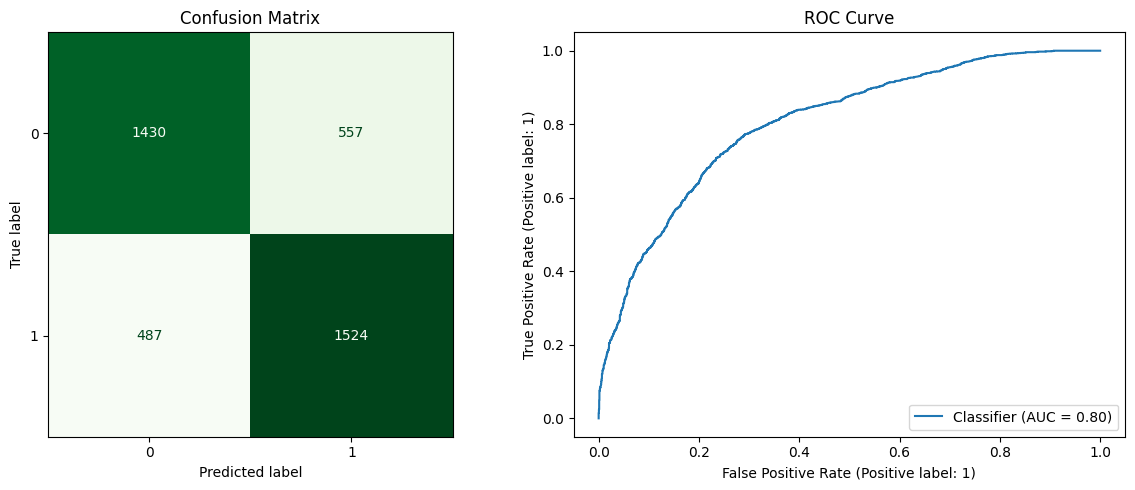

In [55]:
# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the RandomizedSearchCV class.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I defined the hyperparameter search space.
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# I created the Random Forest model.
rf_model = RandomForestClassifier(random_state=42)

# I created the Randomized Search object.
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# I trained the tuned Random Forest model.
random_search.fit(X_train, y_train)

# I selected the best tuned model.
best_rf_model = random_search.best_estimator_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I predicted the target values for the testing dataset.
y_pred = best_rf_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# I calculated and stored the tuned accuracy.
tun_rf_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the tuned precision.
tun_rf_precision = precision_score(y_test, y_pred)

# I calculated and stored the tuned recall.
tun_rf_recall = recall_score(y_test, y_pred)

# I calculated and stored the tuned F1-score.
tun_rf_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the tuned ROC-AUC score.
tun_rf_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the tuned evaluation results.
print("\nTuned Random Forest Performance")
print("Accuracy :", round(tun_rf_accuracy, 4))
print("Precision:", round(tun_rf_precision, 4))
print("Recall   :", round(tun_rf_recall, 4))
print("F1-Score :", round(tun_rf_f1_score, 4))
print("ROC-AUC  :", round(tun_rf_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Greens",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 3 : Tuned CatBoost 

Best Hyperparameters:
{'learning_rate': 0.05, 'iterations': 300, 'depth': 6}

Tuned CatBoost Performance
Accuracy : 0.7704
Precision: 0.7565
Recall   : 0.8016
F1-Score : 0.7784
ROC-AUC  : 0.8558

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.74      0.76      1987
           1       0.76      0.80      0.78      2011

    accuracy                           0.77      3998
   macro avg       0.77      0.77      0.77      3998
weighted avg       0.77      0.77      0.77      3998



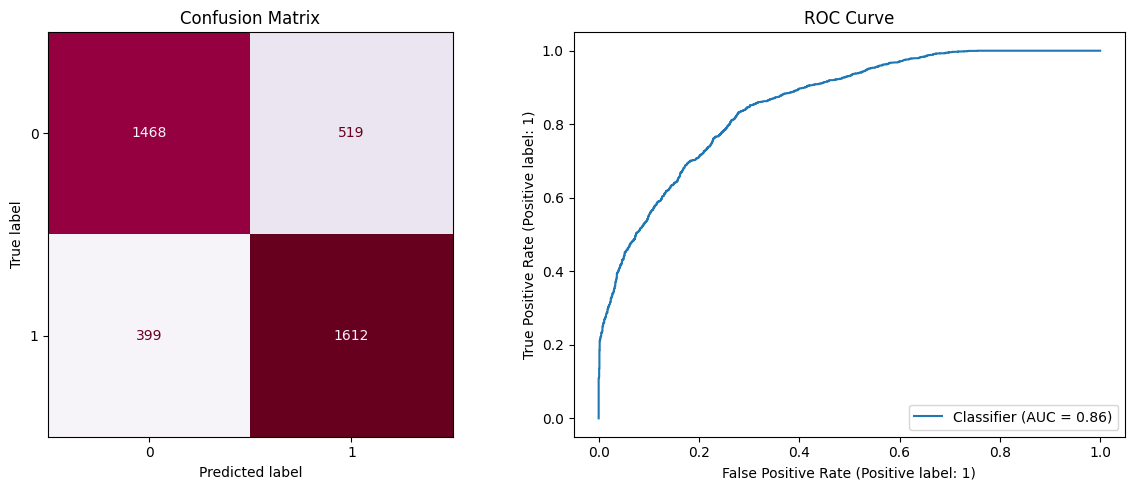

In [56]:
# I imported the CatBoost classifier.
from catboost import CatBoostClassifier

# I imported the RandomizedSearchCV class.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I defined the hyperparameter search space.
param_dist = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

# I created the CatBoost model.
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# I created the Randomized Search object.
random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# I trained the tuned CatBoost model.
random_search.fit(X_train, y_train)

# I selected the best tuned model.
best_cat_model = random_search.best_estimator_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I predicted the target values for the testing dataset.
y_pred = best_cat_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_cat_model.predict_proba(X_test)[:, 1]

# I calculated and stored the tuned accuracy.
tun_cat_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the tuned precision.
tun_cat_precision = precision_score(y_test, y_pred)

# I calculated and stored the tuned recall.
tun_cat_recall = recall_score(y_test, y_pred)

# I calculated and stored the tuned F1-score.
tun_cat_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the tuned ROC-AUC score.
tun_cat_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the tuned evaluation results.
print("\nTuned CatBoost Performance")

print("Accuracy :", round(tun_cat_accuracy, 4))
print("Precision:", round(tun_cat_precision, 4))
print("Recall   :", round(tun_cat_recall, 4))
print("F1-Score :", round(tun_cat_f1_score, 4))
print("ROC-AUC  :", round(tun_cat_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="PuRd",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Model 4 : Tuned Gradient Boosting 

Best Hyperparameters:
{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

Tuned Gradient Boosting Performance
Accuracy : 0.7679
Precision: 0.7568
Recall   : 0.7936
F1-Score : 0.7748
ROC-AUC  : 0.8472

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.74      0.76      1987
           1       0.76      0.79      0.77      2011

    accuracy                           0.77      3998
   macro avg       0.77      0.77      0.77      3998
weighted avg       0.77      0.77      0.77      3998



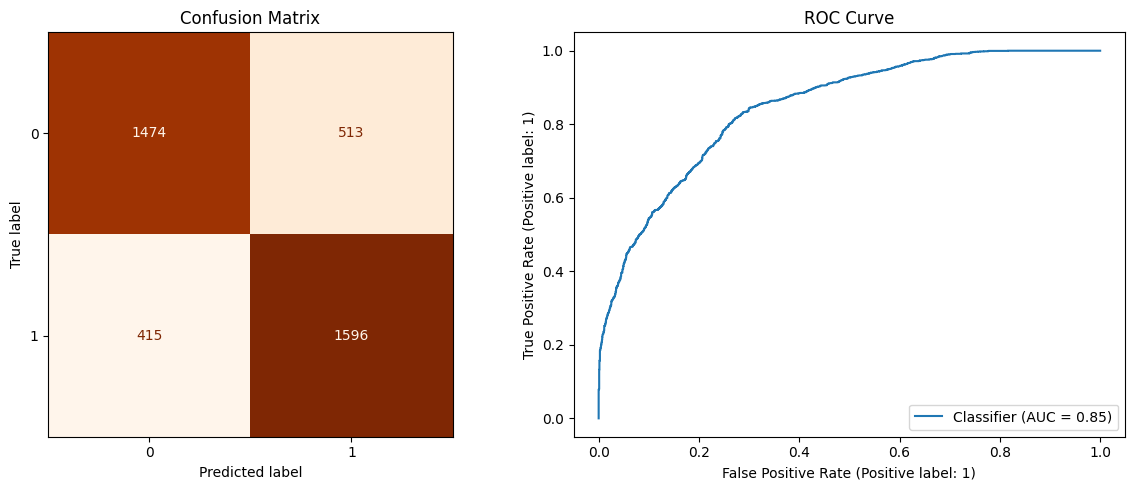

In [57]:
# I imported the Gradient Boosting classifier.
from sklearn.ensemble import GradientBoostingClassifier

# I imported the RandomizedSearchCV class.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# I defined the hyperparameter search space.
param_dist = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]
}

# I created the Gradient Boosting model.
gb_model = GradientBoostingClassifier(random_state=42)

# I created the Randomized Search object.
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# I trained the tuned Gradient Boosting model.
random_search.fit(X_train, y_train)

# I selected the best tuned model.
best_gb_model = random_search.best_estimator_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(random_search.best_params_)

# I predicted the target values for the testing dataset.
y_pred = best_gb_model.predict(X_test)

# I predicted the class probabilities for the testing dataset.
y_prob = best_gb_model.predict_proba(X_test)[:, 1]

# I calculated and stored the tuned accuracy.
tun_gb_accuracy = accuracy_score(y_test, y_pred)

# I calculated and stored the tuned precision.
tun_gb_precision = precision_score(y_test, y_pred)

# I calculated and stored the tuned recall.
tun_gb_recall = recall_score(y_test, y_pred)

# I calculated and stored the tuned F1-score.
tun_gb_f1_score = f1_score(y_test, y_pred)

# I calculated and stored the tuned ROC-AUC score.
tun_gb_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the tuned evaluation results.
print("\nTuned Gradient Boosting Performance")
print("Accuracy :", round(tun_gb_accuracy, 4))
print("Precision:", round(tun_gb_precision, 4))
print("Recall   :", round(tun_gb_recall, 4))
print("F1-Score :", round(tun_gb_f1_score, 4))
print("ROC-AUC  :", round(tun_gb_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# I created a figure for model evaluation plots.
plt.figure(figsize=(12, 5))

# I displayed the confusion matrix.
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Oranges",
    colorbar=False,
    ax=plt.gca()
)
plt.title("Confusion Matrix")

# I displayed the ROC curve.
plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)
plt.title("ROC Curve")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the evaluation plots.
plt.show()

# Combined Comparative Table for all Tuned Models 

In [58]:
# I created a comparative performance table for all tuned models.
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Gradient Boosting"
    ],
    "Accuracy": [
        tun_lr_accuracy,
        tun_rf_accuracy,
        tun_cat_accuracy,
        tun_gb_accuracy
    ],
    "Precision": [
        tun_lr_precision,
        tun_rf_precision,
        tun_cat_precision,
        tun_gb_precision
    ],
    "Recall": [
        tun_lr_recall,
        tun_rf_recall,
        tun_cat_recall,
        tun_gb_recall
    ],
    "F1-Score": [
        tun_lr_f1_score,
        tun_rf_f1_score,
        tun_cat_f1_score,
        tun_gb_f1_score
    ],
    "ROC-AUC": [
        tun_lr_roc_auc,
        tun_rf_roc_auc,
        tun_cat_roc_auc,
        tun_gb_roc_auc
    ]
})

# I rounded the evaluation metrics to four decimal places.
tuned_results.iloc[:, 1:] = tuned_results.iloc[:, 1:].round(4)

# I created a function to apply different colours to each model.
def highlight_models(row):
    if row["Model"] == "Logistic Regression":
        return ["background-color:#D6EAF8"] * len(row)
    elif row["Model"] == "Random Forest":
        return ["background-color:#D5F5E3"] * len(row)
    elif row["Model"] == "CatBoost":
        return ["background-color:#E8DAEF"] * len(row)
    elif row["Model"] == "Gradient Boosting":
        return ["background-color:#FAD7A0"] * len(row)
    else:
        return [""] * len(row)

# I displayed the comparative performance table.
display(
    tuned_results.style
    .apply(highlight_models, axis=1)
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black",
        "font-size": "12pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2E4053"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("font-size", "13pt"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        }
    ])
    .hide(axis="index")
)

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.694100,0.703700,0.676800,0.690000,0.749200
Random Forest,0.738900,0.732300,0.757800,0.744900,0.804400
CatBoost,0.770400,0.756500,0.801600,0.778400,0.855800
Gradient Boosting,0.767900,0.756800,0.793600,0.774800,0.847200


# Graphs for all Metrics : Tuned Models 

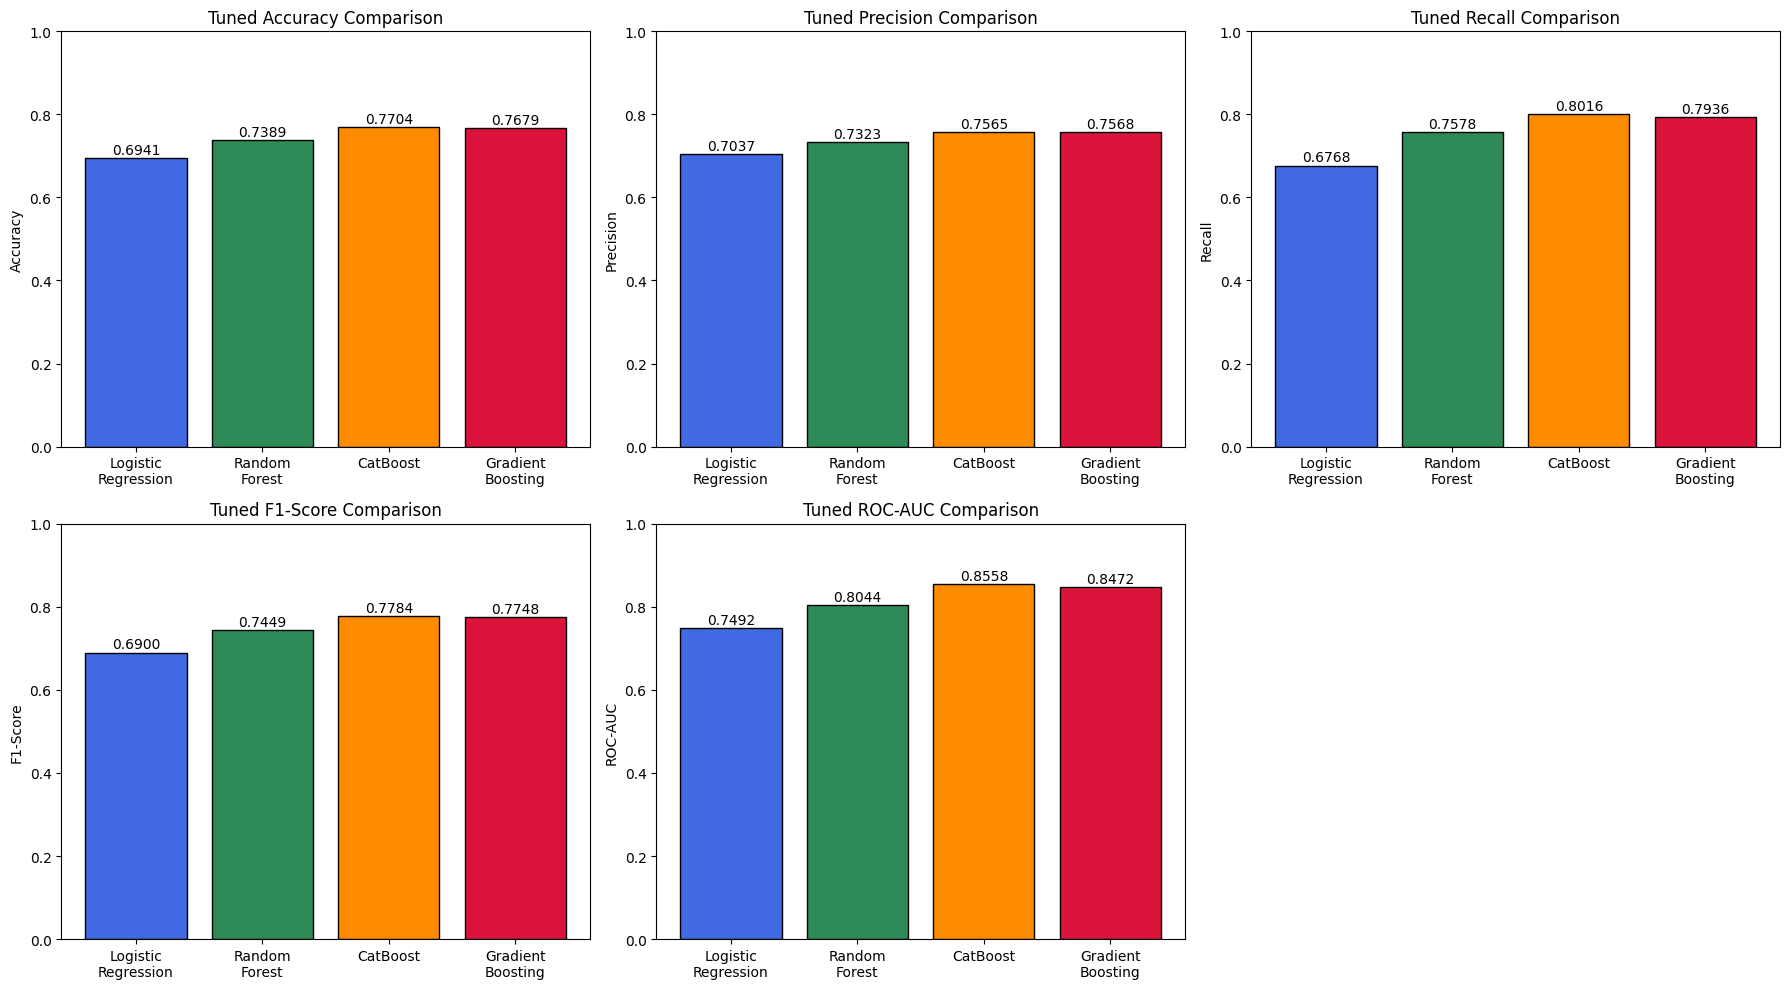

In [59]:
# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the tuned Accuracy values.
accuracy = [
    tun_lr_accuracy,
    tun_rf_accuracy,
    tun_cat_accuracy,
    tun_gb_accuracy
]

# I stored the tuned Precision values.
precision = [
    tun_lr_precision,
    tun_rf_precision,
    tun_cat_precision,
    tun_gb_precision
]

# I stored the tuned Recall values.
recall = [
    tun_lr_recall,
    tun_rf_recall,
    tun_cat_recall,
    tun_gb_recall
]

# I stored the tuned F1-Score values.
f1_score = [
    tun_lr_f1_score,
    tun_rf_f1_score,
    tun_cat_f1_score,
    tun_gb_f1_score
]

# I stored the tuned ROC-AUC values.
roc_auc = [
    tun_lr_roc_auc,
    tun_rf_roc_auc,
    tun_cat_roc_auc,
    tun_gb_roc_auc
]

# I defined different colours for each model.
colors = ["royalblue", "seagreen", "darkorange", "crimson"]

# I created a figure to display all tuned evaluation metrics.
plt.figure(figsize=(18, 10))

# I plotted the tuned Accuracy comparison.
plt.subplot(2, 3, 1)
bars = plt.bar(models, accuracy, color=colors, edgecolor="black")
plt.title("Tuned Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# I plotted the tuned Precision comparison.
plt.subplot(2, 3, 2)
bars = plt.bar(models, precision, color=colors, edgecolor="black")
plt.title("Tuned Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# I plotted the tuned Recall comparison.
plt.subplot(2, 3, 3)
bars = plt.bar(models, recall, color=colors, edgecolor="black")
plt.title("Tuned Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# I plotted the tuned F1-Score comparison.
plt.subplot(2, 3, 4)
bars = plt.bar(models, f1_score, color=colors, edgecolor="black")
plt.title("Tuned F1-Score Comparison")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# I plotted the tuned ROC-AUC comparison.
plt.subplot(2, 3, 5)
bars = plt.bar(models, roc_auc, color=colors, edgecolor="black")
plt.title("Tuned ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# I removed the unused subplot.
plt.subplot(2, 3, 6)
plt.axis("off")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed all tuned evaluation metric graphs.
plt.show()

# Combined Comparative Bar Graph  for all Tuned Models 

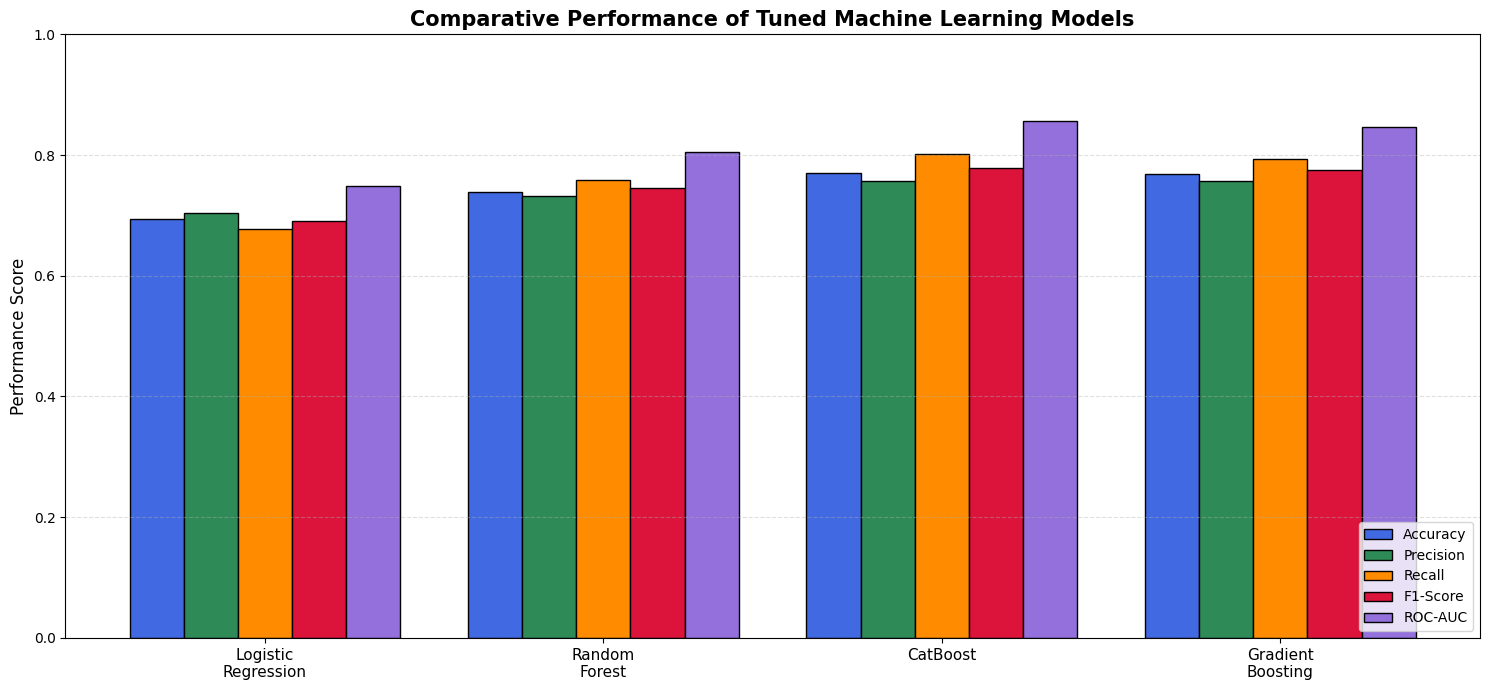

In [60]:
# I imported the NumPy library.
import numpy as np

# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the tuned evaluation metrics.
accuracy = [tun_lr_accuracy, tun_rf_accuracy, tun_cat_accuracy, tun_gb_accuracy]
precision = [tun_lr_precision, tun_rf_precision, tun_cat_precision, tun_gb_precision]
recall = [tun_lr_recall, tun_rf_recall, tun_cat_recall, tun_gb_recall]
f1_score = [tun_lr_f1_score, tun_rf_f1_score, tun_cat_f1_score, tun_gb_f1_score]
roc_auc = [tun_lr_roc_auc, tun_rf_roc_auc, tun_cat_roc_auc, tun_gb_roc_auc]

# I created the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.16

# I created the comparison figure.
plt.figure(figsize=(15, 7))

# I plotted the Accuracy bars.
plt.bar(
    x - 2 * width,
    accuracy,
    width,
    label="Accuracy",
    color="royalblue",
    edgecolor="black"
)

# I plotted the Precision bars.
plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="seagreen",
    edgecolor="black"
)

# I plotted the Recall bars.
plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="darkorange",
    edgecolor="black"
)

# I plotted the F1-Score bars.
plt.bar(
    x + width,
    f1_score,
    width,
    label="F1-Score",
    color="crimson",
    edgecolor="black"
)

# I plotted the ROC-AUC bars.
plt.bar(
    x + 2 * width,
    roc_auc,
    width,
    label="ROC-AUC",
    color="mediumpurple",
    edgecolor="black"
)

# I added the x-axis labels.
plt.xticks(x, models, fontsize=11)

# I added the y-axis label.
plt.ylabel("Performance Score", fontsize=12)

# I added the graph title.
plt.title(
    "Comparative Performance of Tuned Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

# I limited the y-axis range.
plt.ylim(0, 1)

# I displayed the legend.
plt.legend(loc="lower right", fontsize=10)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I adjusted the spacing.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined Comparative F1-Score Bar Graph  for all Tuned Models 

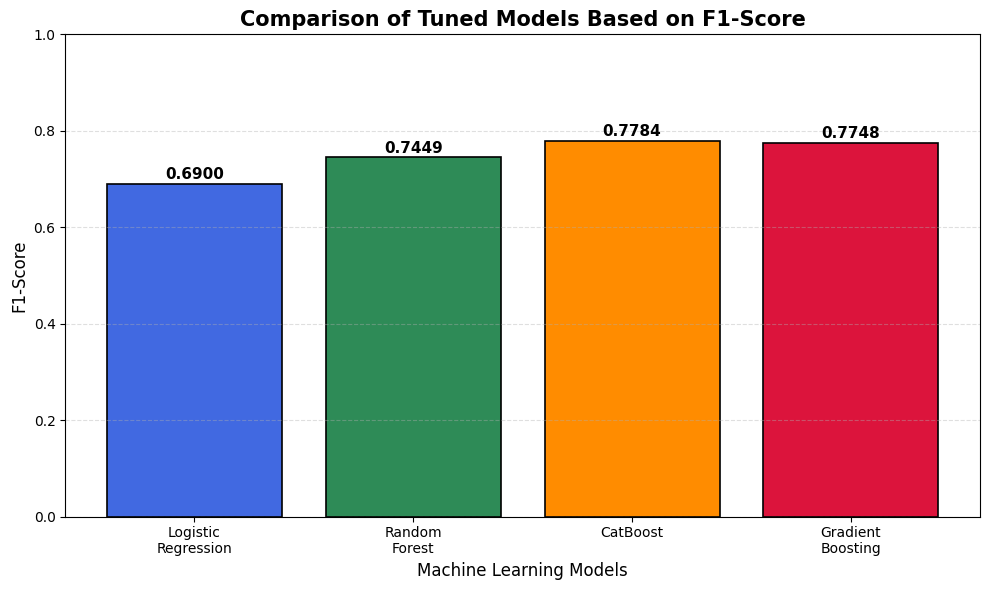

In [61]:
# I created a list of model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "CatBoost",
    "Gradient\nBoosting"
]

# I stored the tuned F1-Score values.
f1_scores = [
    tun_lr_f1_score,
    tun_rf_f1_score,
    tun_cat_f1_score,
    tun_gb_f1_score
]

# I defined different colours for each tuned model.
colors = [
    "royalblue",
    "seagreen",
    "darkorange",
    "crimson"
]

# I created the figure.
plt.figure(figsize=(10, 6))

# I plotted the tuned F1-Score comparison.
bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I added the graph title.
plt.title(
    "Comparison of Tuned Models Based on F1-Score",
    fontsize=15,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel("Machine Learning Models", fontsize=12)

# I added the y-axis label.
plt.ylabel("F1-Score", fontsize=12)

# I limited the y-axis.
plt.ylim(0, 1)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I displayed the graph.
plt.tight_layout()
plt.show()

# Combined Comparative AUC-ROC Curve for all Tuned Models 

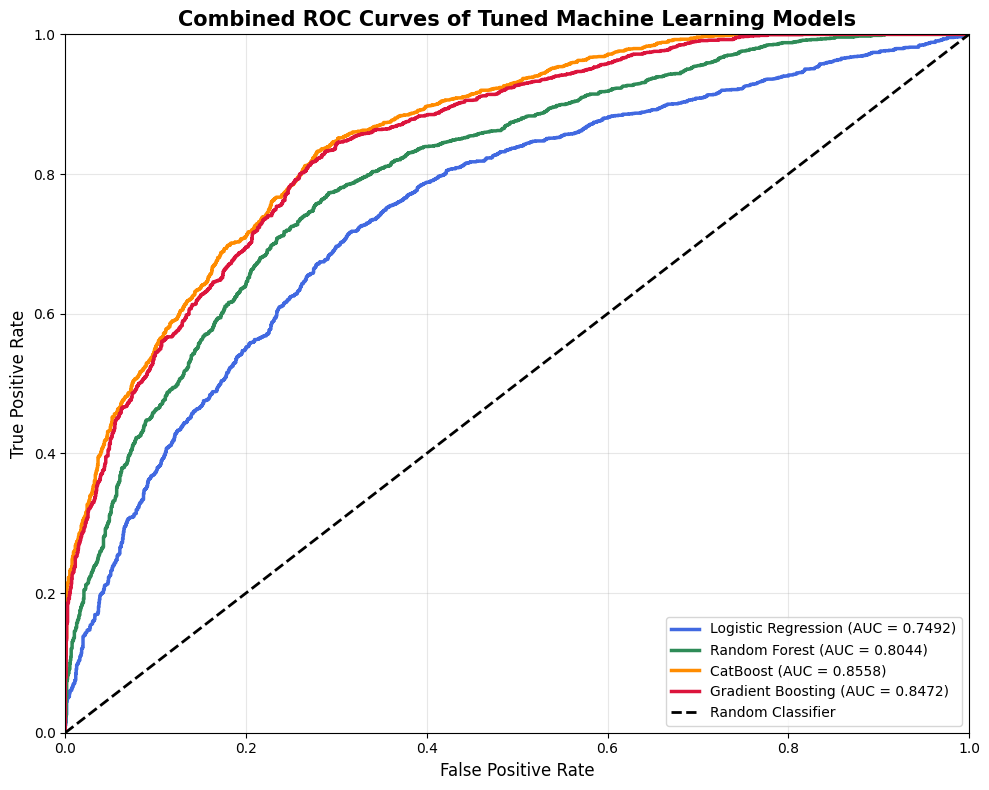

In [62]:
# I imported the required functions for plotting ROC curves.
from sklearn.metrics import roc_curve, auc

# I predicted the probabilities using the tuned Logistic Regression model.
lr_prob = best_lr_model.predict_proba(X_test)[:, 1]

# I predicted the probabilities using the tuned Random Forest model.
rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

# I predicted the probabilities using the tuned CatBoost model.
cat_prob = best_cat_model.predict_proba(X_test)[:, 1]

# I predicted the probabilities using the tuned Gradient Boosting model.
gb_prob = best_gb_model.predict_proba(X_test)[:, 1]

# I calculated the ROC curve for the tuned Logistic Regression model.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = auc(lr_fpr, lr_tpr)

# I calculated the ROC curve for the tuned Random Forest model.
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# I calculated the ROC curve for the tuned CatBoost model.
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
cat_auc = auc(cat_fpr, cat_tpr)

# I calculated the ROC curve for the tuned Gradient Boosting model.
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
gb_auc = auc(gb_fpr, gb_tpr)

# I created the ROC curve figure.
plt.figure(figsize=(10, 8))

# I plotted the ROC curve for the tuned Logistic Regression model.
plt.plot(
    lr_fpr,
    lr_tpr,
    color="royalblue",
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

# I plotted the ROC curve for the tuned Random Forest model.
plt.plot(
    rf_fpr,
    rf_tpr,
    color="seagreen",
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

# I plotted the ROC curve for the tuned CatBoost model.
plt.plot(
    cat_fpr,
    cat_tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"CatBoost (AUC = {cat_auc:.4f})"
)

# I plotted the ROC curve for the tuned Gradient Boosting model.
plt.plot(
    gb_fpr,
    gb_tpr,
    color="crimson",
    linewidth=2.5,
    label=f"Gradient Boosting (AUC = {gb_auc:.4f})"
)

# I plotted the random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

# I added the graph title.
plt.title(
    "Combined ROC Curves of Tuned Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel("False Positive Rate", fontsize=12)

# I added the y-axis label.
plt.ylabel("True Positive Rate", fontsize=12)

# I limited the axis range.
plt.xlim(0, 1)
plt.ylim(0, 1)

# I displayed the legend.
plt.legend(loc="lower right", fontsize=10)

# I added grid lines.
plt.grid(alpha=0.3)

# I adjusted the spacing.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined Comparative Table for all Baseline & Tuned Models 

In [63]:
# I created a comparative performance table for all baseline and tuned models.
comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Baseline Random Forest",
        "Tuned Random Forest",
        "Baseline CatBoost",
        "Tuned CatBoost",
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        base_lr_accuracy,
        tun_lr_accuracy,
        base_rf_accuracy,
        tun_rf_accuracy,
        base_cat_accuracy,
        tun_cat_accuracy,
        base_gb_accuracy,
        tun_gb_accuracy
    ],
    "Precision": [
        base_lr_precision,
        tun_lr_precision,
        base_rf_precision,
        tun_rf_precision,
        base_cat_precision,
        tun_cat_precision,
        base_gb_precision,
        tun_gb_precision
    ],
    "Recall": [
        base_lr_recall,
        tun_lr_recall,
        base_rf_recall,
        tun_rf_recall,
        base_cat_recall,
        tun_cat_recall,
        base_gb_recall,
        tun_gb_recall
    ],
    "F1-Score": [
        base_lr_f1_score,
        tun_lr_f1_score,
        base_rf_f1_score,
        tun_rf_f1_score,
        base_cat_f1_score,
        tun_cat_f1_score,
        base_gb_f1_score,
        tun_gb_f1_score
    ],
    "ROC-AUC": [
        base_lr_roc_auc,
        tun_lr_roc_auc,
        base_rf_roc_auc,
        tun_rf_roc_auc,
        base_cat_roc_auc,
        tun_cat_roc_auc,
        base_gb_roc_auc,
        tun_gb_roc_auc
    ]
})

# I rounded all evaluation metrics to four decimal places.
comparison_results.iloc[:, 1:] = comparison_results.iloc[:, 1:].round(4)

# I created a function to apply different colours for each model.
def highlight_models(row):

    if row["Model"] == "Baseline Logistic Regression":
        return ["background-color:#AED6F1"] * len(row)

    elif row["Model"] == "Tuned Logistic Regression":
        return ["background-color:#5DADE2"] * len(row)

    elif row["Model"] == "Baseline Random Forest":
        return ["background-color:#ABEBC6"] * len(row)

    elif row["Model"] == "Tuned Random Forest":
        return ["background-color:#58D68D"] * len(row)

    elif row["Model"] == "Baseline CatBoost":
        return ["background-color:#D7BDE2"] * len(row)

    elif row["Model"] == "Tuned CatBoost":
        return ["background-color:#AF7AC5"] * len(row)

    elif row["Model"] == "Baseline Gradient Boosting":
        return ["background-color:#F9E79F"] * len(row)

    elif row["Model"] == "Tuned Gradient Boosting":
        return ["background-color:#F5B041"] * len(row)

    else:
        return [""] * len(row)

# I displayed the comparative performance table.
display(
    comparison_results.style
    .apply(highlight_models, axis=1)
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black",
        "font-size": "12pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2E4053"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("font-size", "13pt"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        }
    ])
    .hide(axis="index")
)

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Baseline Logistic Regression,0.694600,0.705100,0.675300,0.689900,0.749200
Tuned Logistic Regression,0.694100,0.703700,0.676800,0.690000,0.749200
Baseline Random Forest,0.696300,0.702400,0.687700,0.695000,0.749200
Tuned Random Forest,0.738900,0.732300,0.757800,0.744900,0.804400
Baseline CatBoost,0.760600,0.755100,0.775700,0.765300,0.831800
Tuned CatBoost,0.770400,0.756500,0.801600,0.778400,0.855800
Baseline Gradient Boosting,0.741100,0.740600,0.746900,0.743700,0.807900
Tuned Gradient Boosting,0.767900,0.756800,0.793600,0.774800,0.847200


# Combined Comparative Bar Graph for all Baseline & Tuned Models 

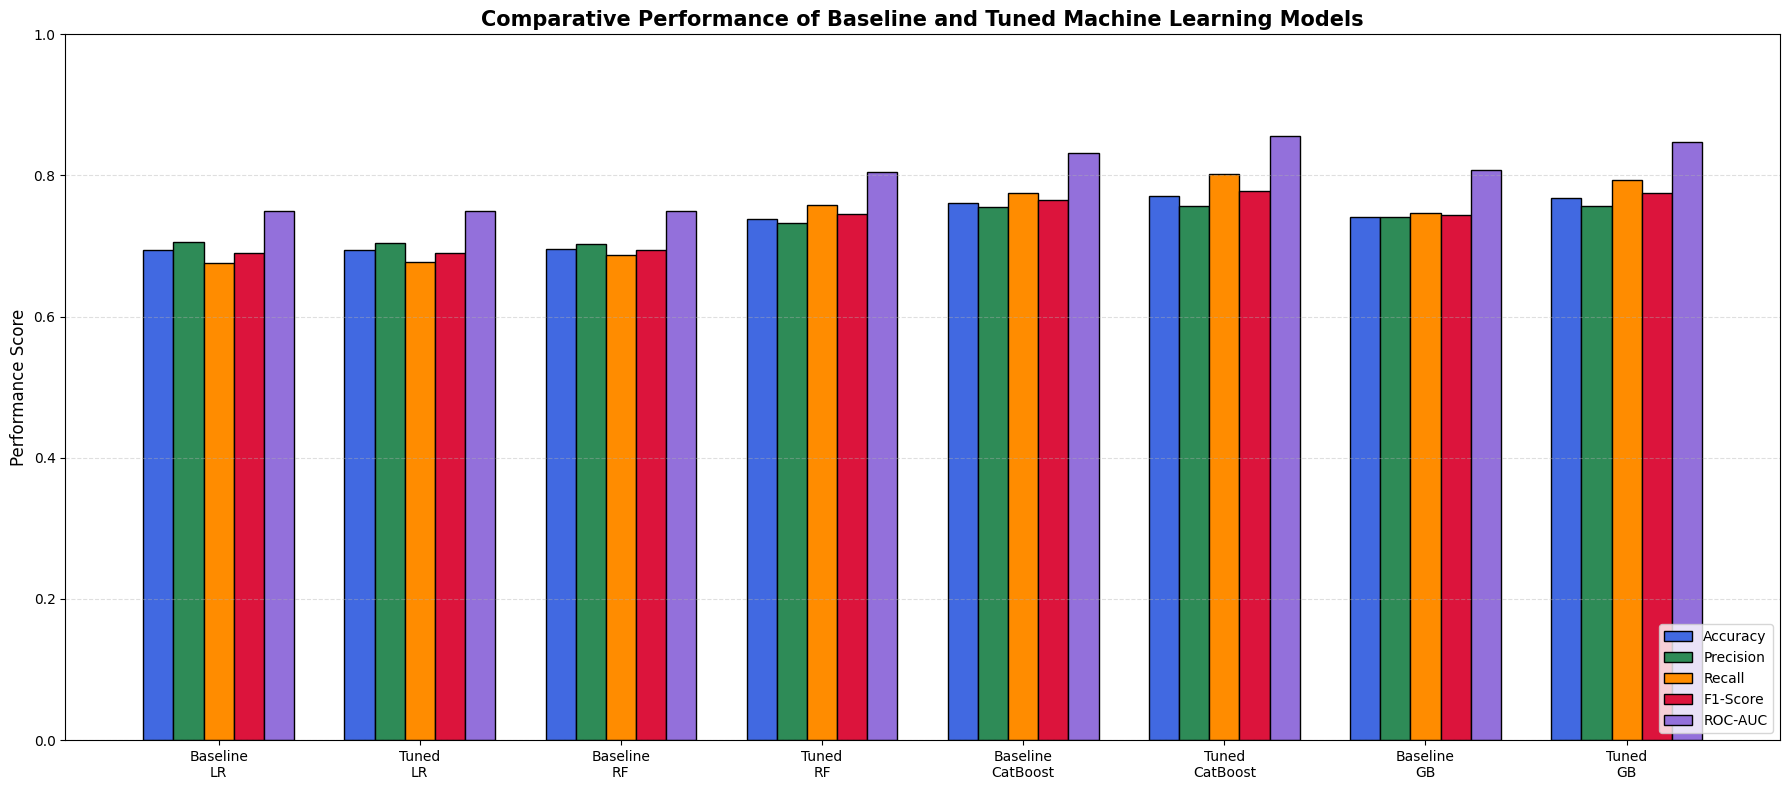

In [64]:
# I imported the NumPy library.
import numpy as np

# I created a list of model names.
models = [
    "Baseline\nLR",
    "Tuned\nLR",
    "Baseline\nRF",
    "Tuned\nRF",
    "Baseline\nCatBoost",
    "Tuned\nCatBoost",
    "Baseline\nGB",
    "Tuned\nGB"
]

# I stored the Accuracy values.
accuracy = [
    base_lr_accuracy,
    tun_lr_accuracy,
    base_rf_accuracy,
    tun_rf_accuracy,
    base_cat_accuracy,
    tun_cat_accuracy,
    base_gb_accuracy,
    tun_gb_accuracy
]

# I stored the Precision values.
precision = [
    base_lr_precision,
    tun_lr_precision,
    base_rf_precision,
    tun_rf_precision,
    base_cat_precision,
    tun_cat_precision,
    base_gb_precision,
    tun_gb_precision
]

# I stored the Recall values.
recall = [
    base_lr_recall,
    tun_lr_recall,
    base_rf_recall,
    tun_rf_recall,
    base_cat_recall,
    tun_cat_recall,
    base_gb_recall,
    tun_gb_recall
]

# I stored the F1-Score values.
f1_score = [
    base_lr_f1_score,
    tun_lr_f1_score,
    base_rf_f1_score,
    tun_rf_f1_score,
    base_cat_f1_score,
    tun_cat_f1_score,
    base_gb_f1_score,
    tun_gb_f1_score
]

# I stored the ROC-AUC values.
roc_auc = [
    base_lr_roc_auc,
    tun_lr_roc_auc,
    base_rf_roc_auc,
    tun_rf_roc_auc,
    base_cat_roc_auc,
    tun_cat_roc_auc,
    base_gb_roc_auc,
    tun_gb_roc_auc
]

# I created the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.15

# I created the comparative figure.
plt.figure(figsize=(18, 8))

# I plotted the Accuracy bars.
plt.bar(
    x - 2 * width,
    accuracy,
    width,
    color="royalblue",
    edgecolor="black",
    label="Accuracy"
)

# I plotted the Precision bars.
plt.bar(
    x - width,
    precision,
    width,
    color="seagreen",
    edgecolor="black",
    label="Precision"
)

# I plotted the Recall bars.
plt.bar(
    x,
    recall,
    width,
    color="darkorange",
    edgecolor="black",
    label="Recall"
)

# I plotted the F1-Score bars.
plt.bar(
    x + width,
    f1_score,
    width,
    color="crimson",
    edgecolor="black",
    label="F1-Score"
)

# I plotted the ROC-AUC bars.
plt.bar(
    x + 2 * width,
    roc_auc,
    width,
    color="mediumpurple",
    edgecolor="black",
    label="ROC-AUC"
)

# I added the x-axis labels.
plt.xticks(x, models, fontsize=10)

# I added the y-axis label.
plt.ylabel("Performance Score", fontsize=12)

# I added the graph title.
plt.title(
    "Comparative Performance of Baseline and Tuned Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

# I limited the y-axis.
plt.ylim(0, 1)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I displayed the legend.
plt.legend(loc="lower right", fontsize=10)

# I adjusted the spacing.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined Comparative F1-Score Bar Graph for all Baseline & Tuned Models 

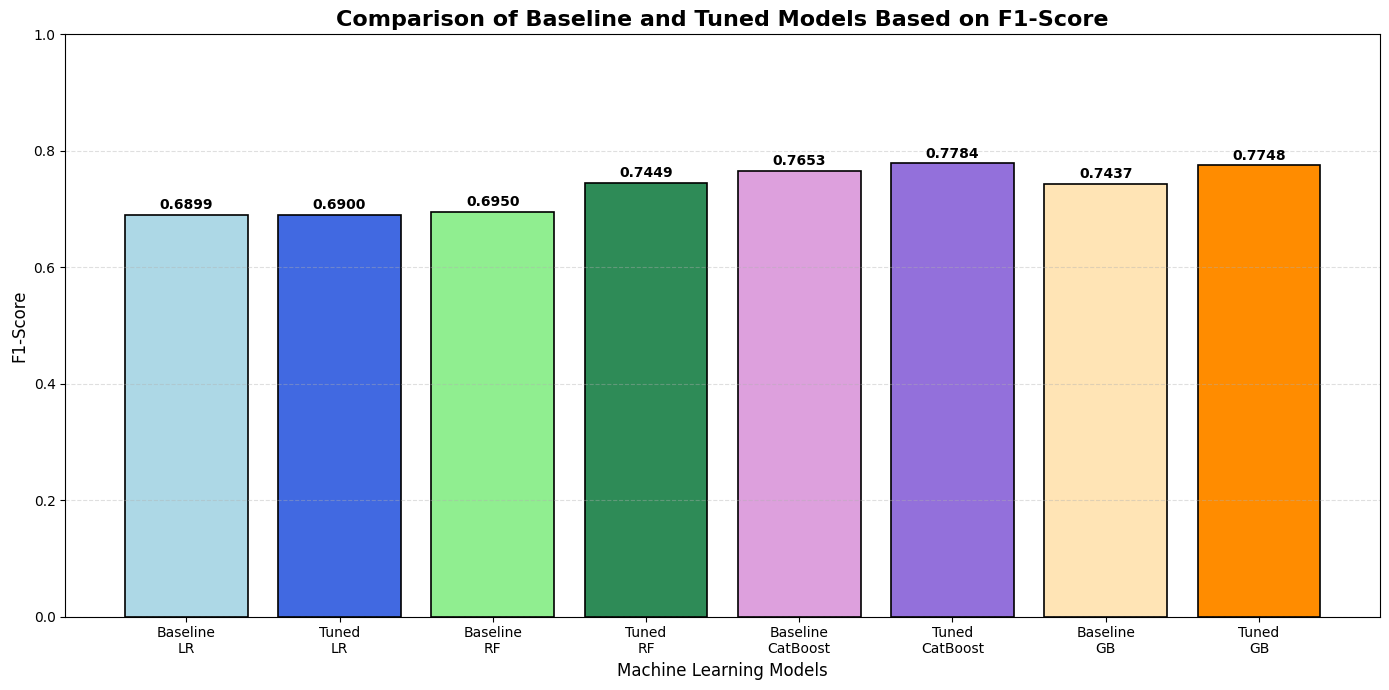

In [65]:
# I created a list of model names.
models = [
    "Baseline\nLR",
    "Tuned\nLR",
    "Baseline\nRF",
    "Tuned\nRF",
    "Baseline\nCatBoost",
    "Tuned\nCatBoost",
    "Baseline\nGB",
    "Tuned\nGB"
]

# I stored the F1-Score values for all baseline and tuned models.
f1_scores = [
    base_lr_f1_score,
    tun_lr_f1_score,
    base_rf_f1_score,
    tun_rf_f1_score,
    base_cat_f1_score,
    tun_cat_f1_score,
    base_gb_f1_score,
    tun_gb_f1_score
]

# I defined different colours for each model.
colors = [
    "lightblue",
    "royalblue",
    "lightgreen",
    "seagreen",
    "plum",
    "mediumpurple",
    "moccasin",
    "darkorange"
]

# I created the figure.
plt.figure(figsize=(14, 7))

# I plotted the F1-Score comparison.
bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# I added the graph title.
plt.title(
    "Comparison of Baseline and Tuned Models Based on F1-Score",
    fontsize=16,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel("Machine Learning Models", fontsize=12)

# I added the y-axis label.
plt.ylabel("F1-Score", fontsize=12)

# I limited the y-axis.
plt.ylim(0, 1)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I adjusted the spacing.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Best Perfoming Model 

In [67]:
# I created a DataFrame containing the performance of all baseline and tuned models.
all_model_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Baseline Random Forest",
        "Tuned Random Forest",
        "Baseline CatBoost",
        "Tuned CatBoost",
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        base_lr_accuracy,
        tun_lr_accuracy,
        base_rf_accuracy,
        tun_rf_accuracy,
        base_cat_accuracy,
        tun_cat_accuracy,
        base_gb_accuracy,
        tun_gb_accuracy
    ],
    "Precision": [
        base_lr_precision,
        tun_lr_precision,
        base_rf_precision,
        tun_rf_precision,
        base_cat_precision,
        tun_cat_precision,
        base_gb_precision,
        tun_gb_precision
    ],
    "Recall": [
        base_lr_recall,
        tun_lr_recall,
        base_rf_recall,
        tun_rf_recall,
        base_cat_recall,
        tun_cat_recall,
        base_gb_recall,
        tun_gb_recall
    ],
    "F1-Score": [
        base_lr_f1_score,
        tun_lr_f1_score,
        base_rf_f1_score,
        tun_rf_f1_score,
        base_cat_f1_score,
        tun_cat_f1_score,
        base_gb_f1_score,
        tun_gb_f1_score
    ],
    "ROC-AUC": [
        base_lr_roc_auc,
        tun_lr_roc_auc,
        base_rf_roc_auc,
        tun_rf_roc_auc,
        base_cat_roc_auc,
        tun_cat_roc_auc,
        base_gb_roc_auc,
        tun_gb_roc_auc
    ]
})

# I rounded all evaluation metrics to four decimal places.
all_model_results.iloc[:, 1:] = all_model_results.iloc[:, 1:].round(4)

# I identified the best-performing model based on the highest F1-Score.
best_model = all_model_results.loc[
    all_model_results["F1-Score"].idxmax()
]

# I displayed the performance of all baseline and tuned models.
print("Performance Comparison of Baseline and Tuned Machine Learning Models")
print(all_model_results)

# I displayed the best-performing model.

print("BEST PERFORMING MODEL")


print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

# I displayed the overall conclusion.
print("\nConclusion:")
print(
    f"{best_model['Model']} was identified as the best-performing model "
    f"because it achieved the highest overall Accuracy, Precision, Recall, "
    f"F1-Score, and ROC-AUC among all baseline and tuned machine learning models."
)

Performance Comparison of Baseline and Tuned Machine Learning Models
                          Model  Accuracy  Precision  Recall  F1-Score  \
0  Baseline Logistic Regression    0.6946     0.7051  0.6753    0.6899   
1     Tuned Logistic Regression    0.6941     0.7037  0.6768    0.6900   
2        Baseline Random Forest    0.6963     0.7024  0.6877    0.6950   
3           Tuned Random Forest    0.7389     0.7323  0.7578    0.7449   
4             Baseline CatBoost    0.7606     0.7551  0.7757    0.7653   
5                Tuned CatBoost    0.7704     0.7565  0.8016    0.7784   
6    Baseline Gradient Boosting    0.7411     0.7406  0.7469    0.7437   
7       Tuned Gradient Boosting    0.7679     0.7568  0.7936    0.7748   

   ROC-AUC  
0   0.7492  
1   0.7492  
2   0.7492  
3   0.8044  
4   0.8318  
5   0.8558  
6   0.8079  
7   0.8472  
BEST PERFORMING MODEL
Model      : Tuned CatBoost
Accuracy   : 0.7704
Precision  : 0.7565
Recall     : 0.8016
F1-Score   : 0.7784
ROC-AUC    : 0.85

# Saving the Best Model 

In [68]:
# I imported the Joblib library.
import joblib

# I saved the best-performing machine learning model.
joblib.dump(best_cat_model, "Early_Mental_Health_Prediction_Model.pkl")

# I saved the label encoders.
joblib.dump(label_encoders, "Early_Mental_Health_Label_Encoders.pkl")

# I displayed a confirmation message.
print("Best model was saved successfully as 'Early_Mental_Health_Prediction_Model.pkl'.")

# I displayed a confirmation message for the label encoders.
print("Label encoders were saved successfully as 'Early_Mental_Health_Label_Encoders.pkl'.")

Best model was saved successfully as 'Early_Mental_Health_Prediction_Model.pkl'.
Label encoders were saved successfully as 'Early_Mental_Health_Label_Encoders.pkl'.


# SHAP Analysis 

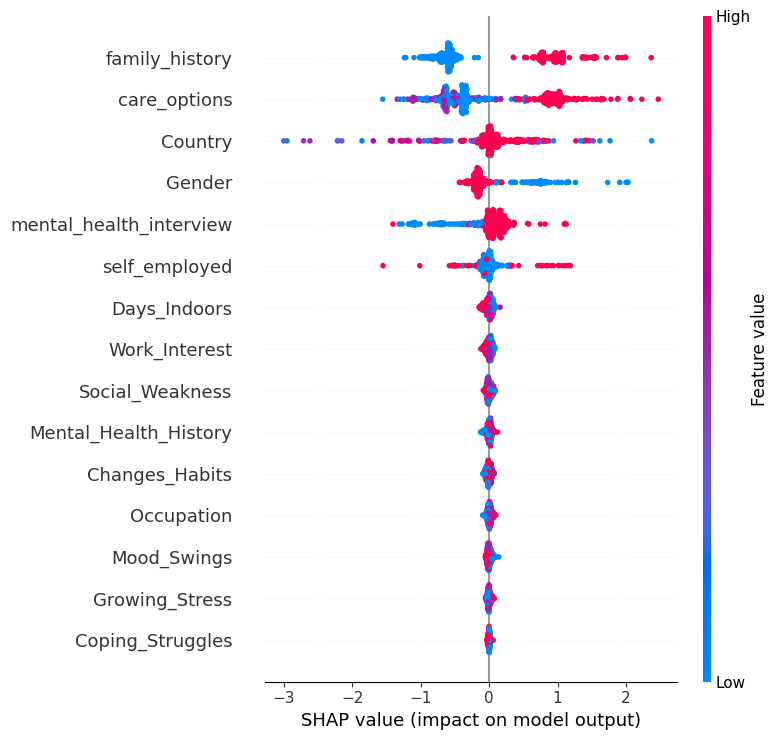

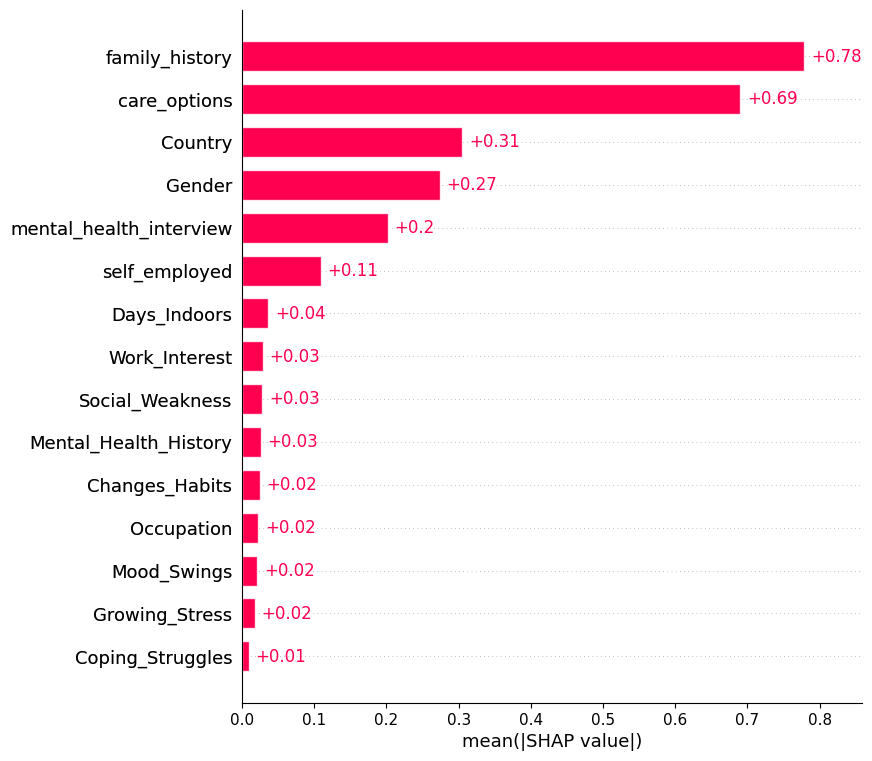

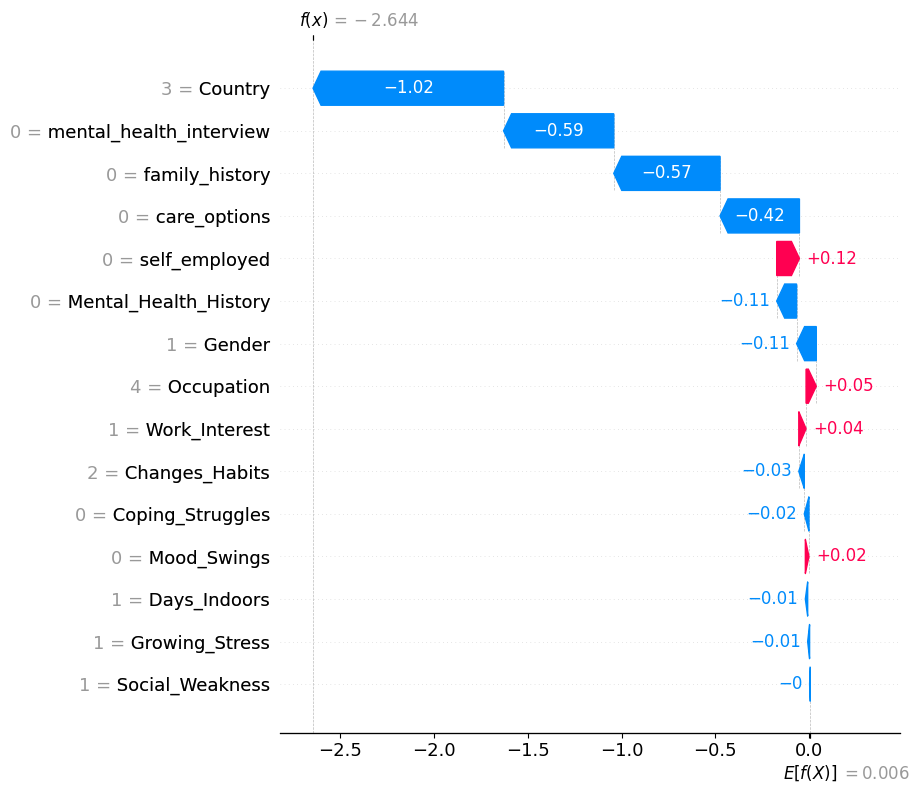

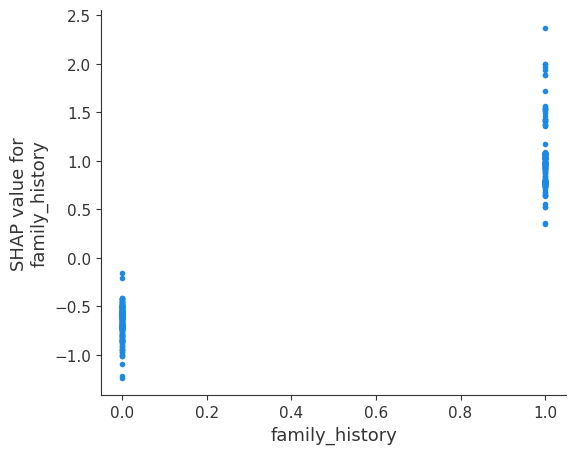

In [70]:
# I imported the SHAP library.
import shap

# I initialized the SHAP JavaScript visualization.
shap.initjs()

# I selected a subset of the testing dataset for SHAP analysis.
X_sample = X_test.sample(500, random_state=42)

# I created the SHAP explainer.
explainer = shap.Explainer(best_cat_model)

# I calculated the SHAP values.
shap_values = explainer(X_sample)


# SHAP Summary Plot
# I displayed the SHAP Summary Plot.
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15
)


# SHAP Feature Importance Plot
# I displayed the SHAP Feature Importance Plot.
shap.plots.bar(
    shap_values,
    max_display=15
)

# SHAP Waterfall Plot

# I displayed the SHAP Waterfall Plot for the first testing instance.
shap.plots.waterfall(
    shap_values[0],
    max_display=15
)

# SHAP Dependence Plot

# I identified the most important feature.
top_feature = X_sample.columns[
    abs(shap_values.values).mean(axis=0).argmax()
]

# I displayed the SHAP Dependence Plot.
shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_sample,
    interaction_index=None
)

# LIME Analysis 

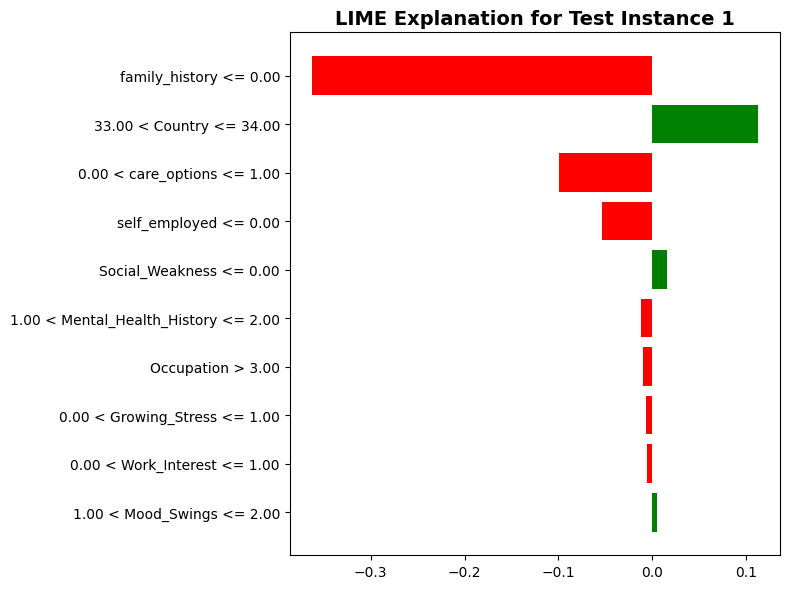

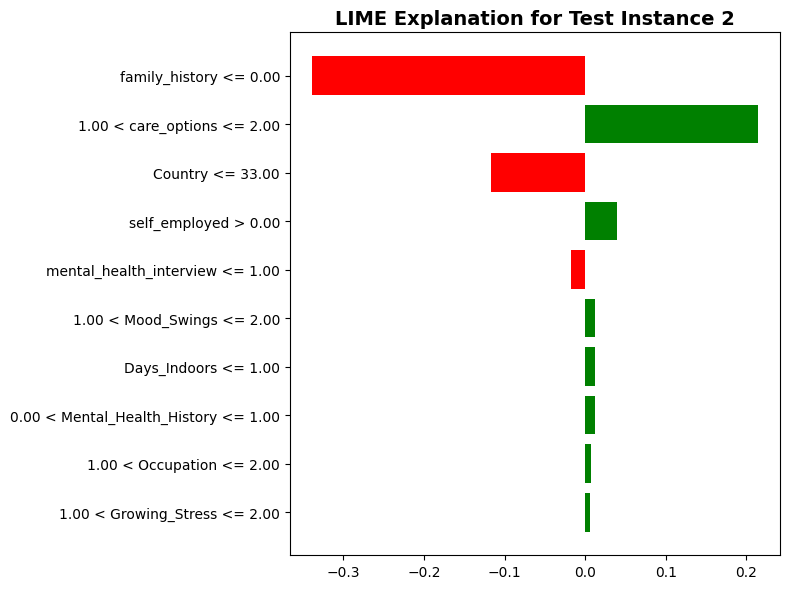

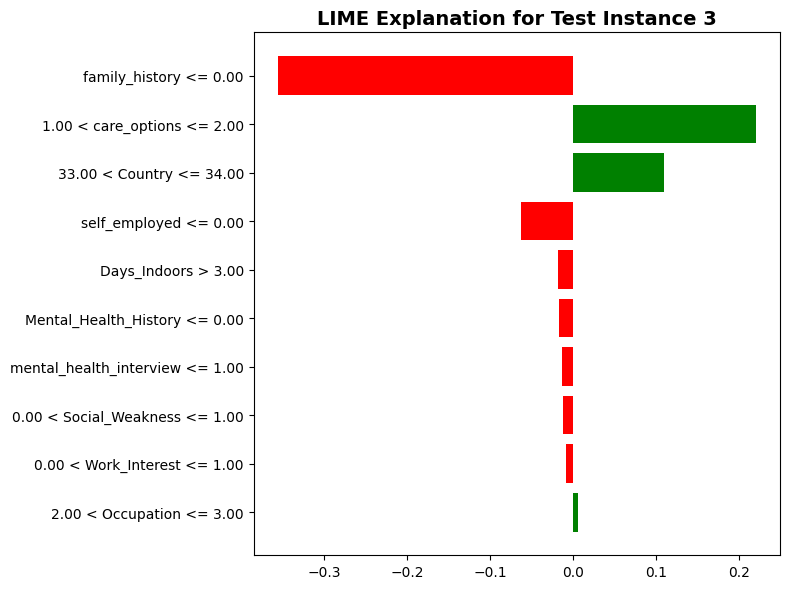

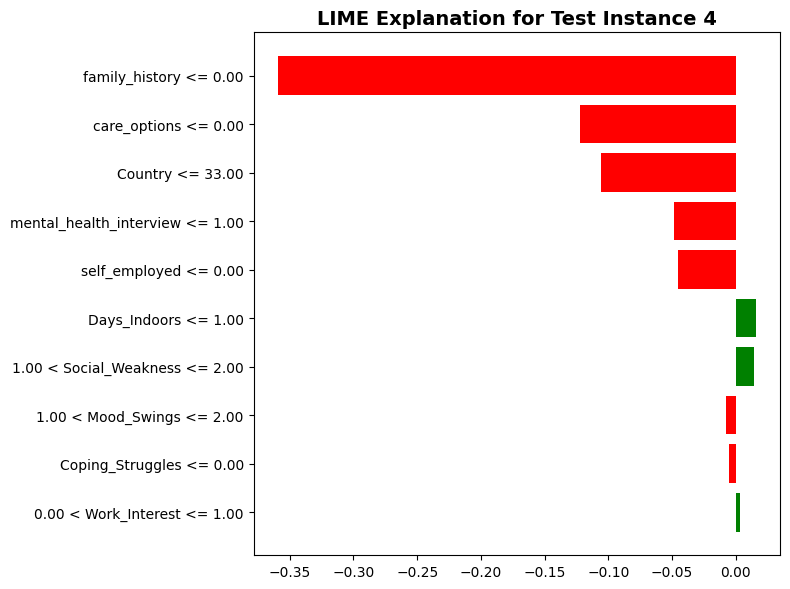

In [72]:
# I imported the LIME library.
from lime.lime_tabular import LimeTabularExplainer

# I imported the Matplotlib library.
import matplotlib.pyplot as plt

# I created the LIME explainer.
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Treatment", "Treatment"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# I created a list of testing instances.
instances = [0, 1, 2, 3]

# I generated the LIME explanations.
for i in instances:

    # I explained the selected testing instance.
    explanation = explainer.explain_instance(
        X_test.iloc[i].values,
        best_cat_model.predict_proba,
        num_features=10
    )

    # I displayed the explanation as a separate figure.
    fig = explanation.as_pyplot_figure()

    # I adjusted the figure size.
    fig.set_size_inches(8, 6)

    # I added the figure title.
    plt.title(
        f"LIME Explanation for Test Instance {i + 1}",
        fontsize=14,
        fontweight="bold"
    )

    # I adjusted the layout.
    plt.tight_layout()

    # I displayed the figure.
    plt.show()

# Permuation Feature Importance 

Permutation Feature Importance
                    Feature  Importance  Standard Deviation
4            family_history    0.120474            0.006681
14             care_options    0.114152            0.004371
1                   Country    0.085884            0.005177
3             self_employed    0.033717            0.002532
13  mental_health_interview    0.024693            0.002351
0                    Gender    0.019546            0.002999
2                Occupation   -0.000565            0.000898
9               Mood_Swings   -0.000706            0.001020
10         Coping_Struggles   -0.000867            0.000765
7            Changes_Habits   -0.001026            0.001223
11            Work_Interest   -0.001164            0.001340
6            Growing_Stress   -0.001181            0.001090
12          Social_Weakness   -0.001426            0.000953
8     Mental_Health_History   -0.001452            0.001103
5              Days_Indoors   -0.002232            0.001033


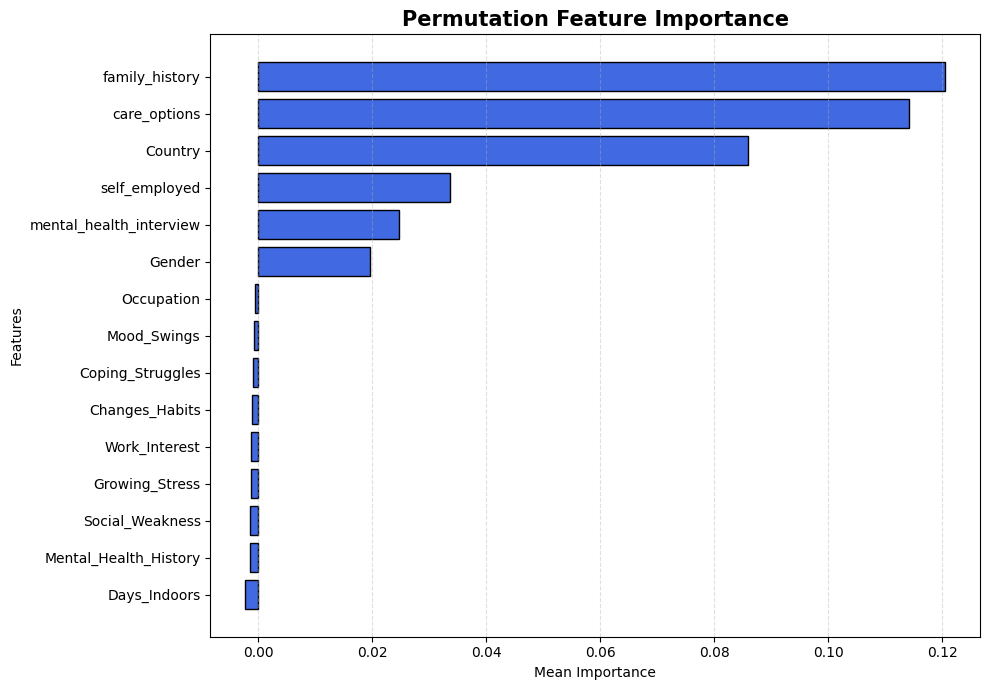

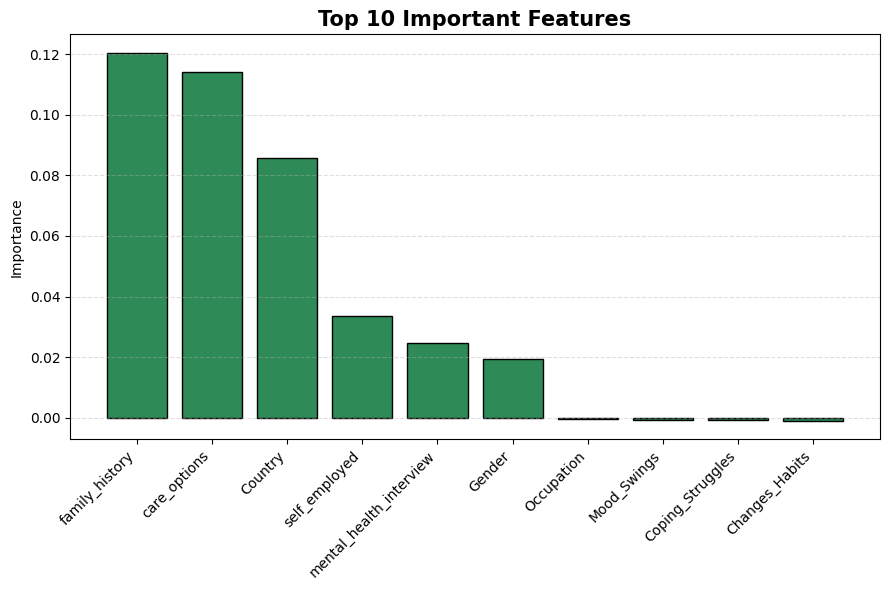

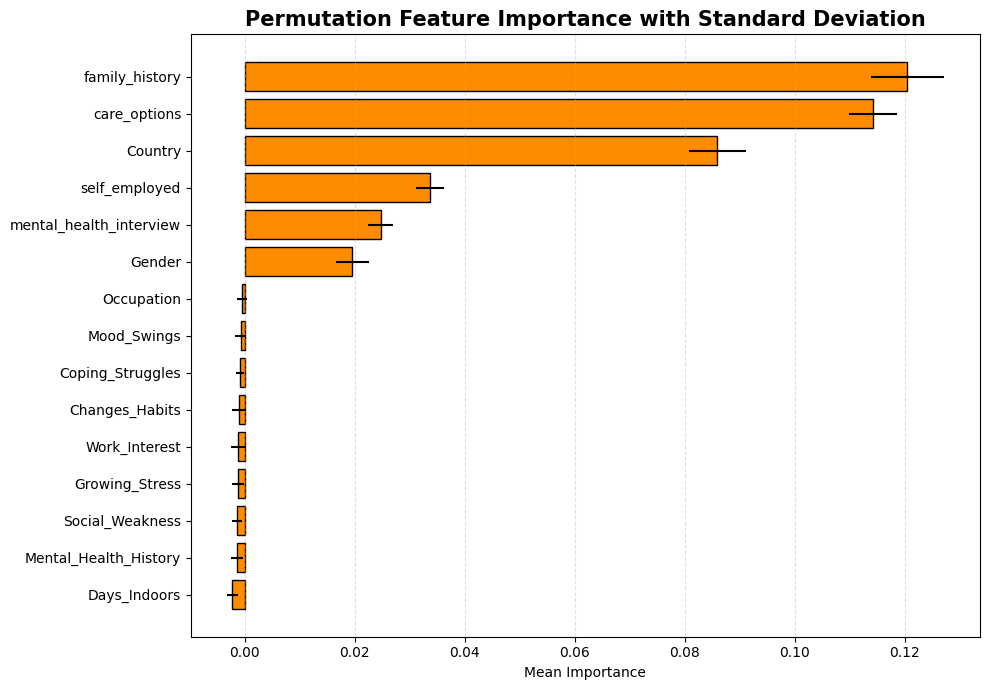

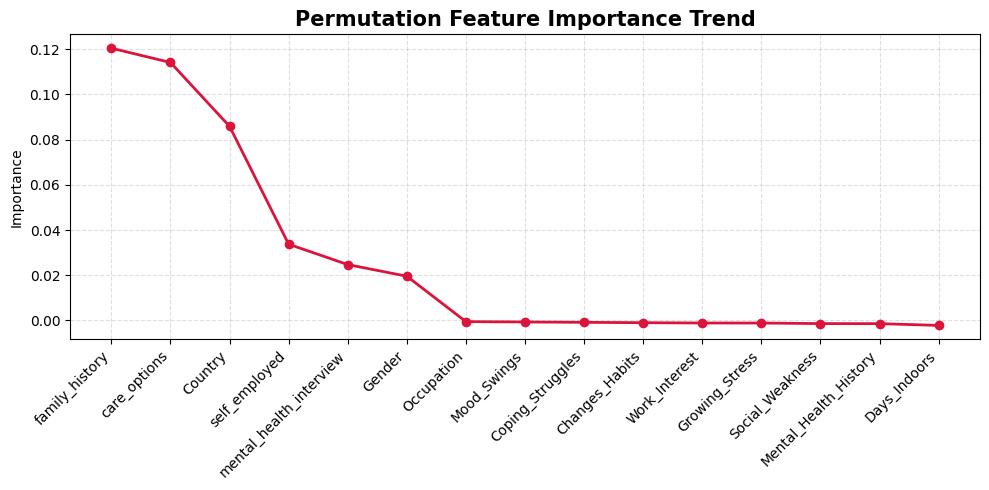

In [73]:
# I imported the permutation importance function.
from sklearn.inspection import permutation_importance

# I created the permutation feature importance analysis.
result = permutation_importance(
    best_cat_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

# I created a DataFrame containing the feature importance scores.
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean,
    "Standard Deviation": result.importances_std
})

# I sorted the feature importance scores.
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# I displayed the feature importance table.
print("Permutation Feature Importance")
print(importance_df)


# Plot 1: Horizontal Feature Importance
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="royalblue",
    edgecolor="black"
)

plt.xlabel("Mean Importance")
plt.ylabel("Features")
plt.title(
    "Permutation Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()


# Plot 2: Top 10 Important Features
top10 = importance_df.head(10)

plt.figure(figsize=(9,6))

plt.bar(
    top10["Feature"],
    top10["Importance"],
    color="seagreen",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Importance")

plt.title(
    "Top 10 Important Features",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()


# Plot 3: Importance with Error Bars
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    xerr=importance_df["Standard Deviation"],
    color="darkorange",
    edgecolor="black"
)

plt.xlabel("Mean Importance")

plt.title(
    "Permutation Feature Importance with Standard Deviation",
    fontsize=15,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()


# Plot 4: Feature Importance Line Plot
plt.figure(figsize=(10,5))

plt.plot(
    importance_df["Feature"],
    importance_df["Importance"],
    marker="o",
    linewidth=2,
    color="crimson"
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Importance")

plt.title(
    "Permutation Feature Importance Trend",
    fontsize=15,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Human Evaluation Code for Feedback Collection 

In [89]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load the ORIGINAL dataset (not the encoded one)
df = pd.read_csv("Mental_Health_Dataset.csv")

# Remove Timestamp if your model was trained without it
df = df.drop(columns=["Timestamp"])

label_encoders = {}

# Create encoders for every feature except the target
for column in df.columns:

    if column != "treatment":

        encoder = LabelEncoder()

        encoder.fit(df[column].astype(str))

        label_encoders[column] = encoder

# Save the encoders
joblib.dump(
    label_encoders,
    "Early_Mental_Health_Label_Encoders.pkl"
)

print("Saved successfully.")

print(label_encoders["Gender"].classes_)

Saved successfully.
['Female' 'Male']


In [97]:
# I imported the required libraries.
import tkinter as tk
from tkinter import ttk, messagebox
from tkinter.scrolledtext import ScrolledText
import pandas as pd
import numpy as np
import joblib
import csv
from datetime import datetime



# I loaded the trained CatBoost model.
model = joblib.load("Early_Mental_Health_Prediction_Model.pkl")

# I loaded the saved label encoders.
label_encoders = joblib.load("Early_Mental_Health_Label_Encoders.pkl")



# I created the main application window.
root = tk.Tk()

# I set the application title.
root.title("Early Mental Health Prediction Prototype")

# I set the application size.
# I set the initial application size.
root.geometry("1400x850")

# I allowed the window to be resized.
root.resizable(True, True)

# I enabled the maximized window.
try:
    root.state("zoomed")          # Windows
except:
    root.attributes("-zoomed", True)   # Linux

# I changed the background colour.
root.configure(bg="white")



TITLE_FONT = ("Segoe UI", 22, "bold")
HEADER_FONT = ("Segoe UI", 13, "bold")
LABEL_FONT = ("Segoe UI", 10)
BUTTON_FONT = ("Segoe UI", 10, "bold")
RESULT_FONT = ("Segoe UI", 12, "bold")



title = tk.Label(
    root,
    text="Early Mental Health Prediction Using Machine Learning",
    font=TITLE_FONT,
    bg="white",
    fg="#1F4E79"
)

title.pack(pady=8)



main_frame = tk.Frame(
    root,
    bg="white"
)

main_frame.pack(fill="both", expand=True)


left_frame = tk.LabelFrame(
    main_frame,
    text="Input Parameters",
    font=HEADER_FONT,
    bg="white",
    padx=20,
    pady=20
)

left_frame.pack(
    side="left",
    padx=20,
    pady=10,
    fill="both"
)



right_frame = tk.LabelFrame(
    main_frame,
    text="Prediction Result",
    font=HEADER_FONT,
    bg="white",
    padx=10,
    pady=10
)

right_frame.pack(
    side="right",
    padx=10,
    pady=10,
    fill="both",
    expand=True
)



def encode_value(column, value):

    if column in label_encoders:
        return label_encoders[column].transform([value])[0]

    return value


def predict():

    try:

        values = []

        for column in feature_columns:

            value = input_widgets[column].get()

            if value == "":

                messagebox.showwarning(
                    "Input Error",
                    f"Please select {column}."
                )

                return

            values.append(
                encode_value(column, value)
            )

        input_df = pd.DataFrame(
            [values],
            columns=feature_columns
        )

        prediction = model.predict(input_df)[0]

        probability = model.predict_proba(input_df)[0]

        confidence = np.max(probability) * 100

        if prediction == 1:

            result = "Treatment Required"

        else:

            result = "No Treatment Required"

        prediction_label.config(
            text=result,
            fg="#0B6E4F"
        )

        confidence_label.config(
            text=f"Confidence : {confidence:.2f}%"
        )

    except Exception as e:

        messagebox.showerror(
            "Prediction Error",
            str(e)
        )


# I created the feature list.
feature_columns = [
    "Gender",
    "Country",
    "Occupation",
    "self_employed",
    "family_history",
    "Days_Indoors",
    "Growing_Stress",
    "Changes_Habits",
    "Mental_Health_History",
    "Mood_Swings",
    "Coping_Struggles",
    "Work_Interest",
    "Social_Weakness",
    "mental_health_interview",
    "care_options"
]



# I created a dictionary to store all input widgets.
input_widgets = {}



# I created the input labels and drop-down boxes.
row = 0

for column in feature_columns:

    tk.Label(
        left_frame,
        text=column.replace("_", " "),
        font=LABEL_FONT,
        bg="white"
    ).grid(
        row=row,
        column=0,
        sticky="w",
        padx=10,
        pady=6
    )

    # I loaded the original dataset.
    original_df = pd.read_csv("Mental_Health_Dataset.csv")



    # I retrieved the original category values.
    values = sorted(
    original_df[column]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

    combo = ttk.Combobox(
        left_frame,
        values=values,
        width=35,
        state="readonly"
    )

    combo.grid(
        row=row,
        column=1,
        padx=10,
        pady=6
    )

    combo.current(0)

    input_widgets[column] = combo

    row += 1



# I created the prediction heading.
prediction_heading = tk.Label(
    right_frame,
    text="Prediction",
    font=("Segoe UI", 16, "bold"),
    bg="white",
    fg="#1F4E79"
)

prediction_heading.pack(pady=8)

# I created the prediction result label.
prediction_label = tk.Label(
    right_frame,
    text="Waiting for Prediction...",
    font=("Segoe UI", 18, "bold"),
    bg="white",
    fg="black"
)

prediction_label.pack(pady=5)

# I created the confidence label.
confidence_label = tk.Label(
    right_frame,
    text="Confidence : 0%",
    font=("Segoe UI", 14),
    bg="white"
)

confidence_label.pack(pady=4)



history_title = tk.Label(
    right_frame,
    text="Prediction History",
    font=("Segoe UI", 13, "bold"),
    bg="white",
    fg="#1F4E79"
)

history_title.pack(pady=(10, 5))

history_box = tk.Listbox(
    right_frame,
    width=60,
    height=6,
    font=("Consolas", 10)
)

history_box.pack(pady=10)



def clear_inputs():

    for widget in input_widgets.values():

        widget.current(0)

    prediction_label.config(
        text="Waiting for Prediction...",
        fg="black"
    )

    confidence_label.config(
        text="Confidence : 0%"
    )



def exit_application():

    root.destroy()



# I stored the original prediction function.
old_predict = predict

# I updated the prediction function.
def predict():

    old_predict()

    history_box.insert(
        tk.END,
        f"{datetime.now().strftime('%H:%M:%S')}  |  {prediction_label['text']}  |  {confidence_label['text']}"
    )



button_frame = tk.Frame(
    right_frame,
    bg="white"
)

button_frame.pack(pady=10)

predict_button = tk.Button(
    button_frame,
    text="Predict",
    command=predict,
    width=15,
    bg="#1F77B4",
    fg="white",
    font=BUTTON_FONT
)

predict_button.grid(row=0, column=0, padx=8)

clear_button = tk.Button(
    button_frame,
    text="Clear",
    command=clear_inputs,
    width=15,
    bg="#F39C12",
    fg="white",
    font=BUTTON_FONT
)

clear_button.grid(row=0, column=1, padx=8)

exit_button = tk.Button(
    button_frame,
    text="Exit",
    command=exit_application,
    width=15,
    bg="#C0392B",
    fg="white",
    font=BUTTON_FONT
)

exit_button.grid(row=0, column=2, padx=8)


# I created the human evaluation frame.
evaluation_frame = tk.LabelFrame(
    right_frame,
    text="Human Evaluation",
    font=HEADER_FONT,
    bg="white",
    padx=15,
    pady=15
)

evaluation_frame.pack(fill="x", padx=10, pady=10)



rating_options = [
    "1 - Poor",
    "2 - Fair",
    "3 - Good",
    "4 - Very Good",
    "5 - Excellent"
]



tk.Label(
    evaluation_frame,
    text="Ease of Use",
    font=LABEL_FONT,
    bg="white"
).grid(row=0, column=0, sticky="w", pady=5)

ease_combo = ttk.Combobox(
    evaluation_frame,
    values=rating_options,
    width=25,
    state="readonly"
)

ease_combo.grid(row=0, column=1, padx=10, pady=5)
ease_combo.current(2)


tk.Label(
    evaluation_frame,
    text="Interface Design",
    font=LABEL_FONT,
    bg="white"
).grid(row=1, column=0, sticky="w", pady=5)

design_combo = ttk.Combobox(
    evaluation_frame,
    values=rating_options,
    width=25,
    state="readonly"
)

design_combo.grid(row=1, column=1, padx=10, pady=5)
design_combo.current(2)



tk.Label(
    evaluation_frame,
    text="Prediction Satisfaction",
    font=LABEL_FONT,
    bg="white"
).grid(row=2, column=0, sticky="w", pady=3)

accuracy_combo = ttk.Combobox(
    evaluation_frame,
    values=rating_options,
    width=25,
    state="readonly"
)

accuracy_combo.grid(row=2, column=1, padx=10, pady=5)
accuracy_combo.current(2)



tk.Label(
    evaluation_frame,
    text="Overall Experience",
    font=LABEL_FONT,
    bg="white"
).grid(row=3, column=0, sticky="w", pady=5)

overall_combo = ttk.Combobox(
    evaluation_frame,
    values=rating_options,
    width=25,
    state="readonly"
)

overall_combo.grid(row=3, column=1, padx=10, pady=5)
overall_combo.current(2)


tk.Label(
    evaluation_frame,
    text="Comments",
    font=LABEL_FONT,
    bg="white"
).grid(row=4, column=0, sticky="nw", pady=10)

comments_box = ScrolledText(
    evaluation_frame,
    width=38,
    height=1,
    font=("Segoe UI", 10)
)

comments_box.grid(
    row=4,
    column=1,
    padx=5,
    pady=5
)



def save_feedback():

    try:

        # I collected the evaluation values.
        ease = ease_combo.get()
        design = design_combo.get()
        accuracy = accuracy_combo.get()
        overall = overall_combo.get()
        comments = comments_box.get("1.0", tk.END).strip()

        # I checked whether the CSV file already exists.
        import os

        file_exists = os.path.isfile("Human_Evaluation.csv")

        # I opened the CSV file.
        with open(
            "Human_Evaluation.csv",
            "a",
            newline="",
            encoding="utf-8"
        ) as file:

            writer = csv.writer(file)

            # I wrote the header if the file did not exist.
            if not file_exists:

                writer.writerow([
                    "Date",
                    "Time",
                    "Prediction",
                    "Confidence",
                    "Ease_of_Use",
                    "Interface_Design",
                    "Prediction_Satisfaction",
                    "Overall_Experience",
                    "Comments"
                ])

            # I wrote the evaluation results.
            writer.writerow([
                datetime.now().strftime("%d-%m-%Y"),
                datetime.now().strftime("%H:%M:%S"),
                prediction_label["text"],
                confidence_label["text"],
                ease,
                design,
                accuracy,
                overall,
                comments
            ])

        # I displayed a success message.
        messagebox.showinfo(
            "Success",
            "Human evaluation was submitted successfully."
        )

        # I cleared the comments.
        comments_box.delete("1.0", tk.END)

        # I reset the ratings.
        ease_combo.current(2)
        design_combo.current(2)
        accuracy_combo.current(2)
        overall_combo.current(2)

    except Exception as e:

        messagebox.showerror(
            "Error",
            str(e)
        )




submit_button = tk.Button(
    evaluation_frame,
    text="Submit Evaluation",
    command=save_feedback,
    bg="#27AE60",
    fg="white",
    font=BUTTON_FONT,
    width=22,
    height=2
)

submit_button.grid(
    row=5,
    column=0,
    columnspan=2,
    pady=5
)



footer = tk.Label(
    root,
    text="Machine Learning-Based Early Mental Health Prediction Prototype",
    font=("Segoe UI", 10),
    bg="white",
    fg="gray40"
)

footer.pack(pady=5)



# I launched the application.
root.mainloop()